# CSE 153 Assignment 2: Music Generation with Machine Learning

**Course:** CSE 153 — Music and AI
**Quarter:** Spring 2026
**Submission:** Solo

---

## Overview

This notebook covers two tasks in symbolic music generation using machine learning,
both built on the **Bach Chorale** corpus (available via `music21`):

| # | Task | Model | Output |
|---|------|-------|--------|
| 1 | **Symbolic, Unconditioned Generation** | 2-layer LSTM language model trained on soprano melodies | `symbolic_unconditioned.mid` |
| 2 | **Symbolic, Conditioned Generation — Harmonization** | 2-layer LSTM conditioned on soprano, predicting alto/tenor/bass | `symbolic_conditioned.mid` |

The two tasks share the same dataset and preprocessing pipeline.
Each task is presented in four sections:
1. Data collection, pre-processing, and exploratory analysis
2. Modeling
3. Evaluation
4. Discussion of related work


## Setup

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import random
import math
from collections import Counter, defaultdict

# ── Data / viz ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Music ─────────────────────────────────────────────────────────────────────
from music21 import corpus, note, chord, stream, pitch, environment
from music21 import tempo as m21tempo
import pretty_midi

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}  |  device: {device}")

# Suppress music21 environment messages
env = environment.UserSettings()
env["warnings"] = 0

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120


PyTorch 2.7.1  |  device: cpu


---
## Shared Data Pipeline
Both tasks use the **Bach Chorale corpus** (embedded in `music21`).
This section loads and preprocesses the data once; both task notebooks reference
the objects created here.


### 0.1 Load Chorales from `music21` Corpus

`music21` ships with all ~370 Bach four-part chorales (BWV 250–438) in MusicXML
format. We load every file that parses cleanly and has exactly 4 parts (SATB).


In [2]:
def load_chorales(max_pieces=None, verbose=True):
    """Return list of (soprano, alto, tenor, bass) note-pitch-sequences.

    Each sequence is a list of MIDI pitch integers quantised to quarter-note
    beats. Rests are encoded as REST_TOKEN (= 0).
    """
    REST_TOKEN = 0

    all_paths = corpus.getComposer("bach")
    if max_pieces:
        all_paths = all_paths[:max_pieces]

    results = []
    skipped = 0
    for path in all_paths:
        try:
            score = corpus.parse(path)
        except Exception:
            skipped += 1
            continue

        parts = score.parts
        if len(parts) != 4:
            skipped += 1
            continue

        voices = []
        ok = True
        for part in parts:
            seq = []
            flat = part.flatten()
            # Determine beat resolution: quarter note = 1 beat
            end_offset = float(flat.highestOffset)
            beat = 0.0
            while beat <= end_offset:
                elems = flat.getElementsByOffset(
                    beat, beat + 0.99, includeEndBoundary=False,
                    mustFinishInSpan=False, mustBeginInSpan=False,
                    classList=[note.Note, chord.Chord]
                )
                elems = list(elems)
                if elems:
                    elem = elems[0]
                    if isinstance(elem, note.Note):
                        seq.append(elem.pitch.midi)
                    elif isinstance(elem, chord.Chord):
                        seq.append(max(n.pitch.midi for n in elem.notes))
                else:
                    seq.append(REST_TOKEN)
                beat += 1.0

            if len(seq) < 8:
                ok = False
                break
            voices.append(seq)

        if ok and len(voices) == 4:
            results.append(voices)
        else:
            skipped += 1

    if verbose:
        print(f"Loaded  : {len(results)} chorales")
        print(f"Skipped : {skipped}")
    return results


REST_TOKEN  = 0
START_TOKEN = 128
END_TOKEN   = 129
VOCAB_SIZE  = 130   # MIDI 1-127 + REST(0) + START(128) + END(129)

chorales = load_chorales(verbose=True)


Loaded  : 368 chorales
Skipped : 65


### 0.2 Dataset Statistics


In [3]:
lengths   = [len(c[0]) for c in chorales]
all_sop   = [p for c in chorales for p in c[0] if p != REST_TOKEN]
all_alto  = [p for c in chorales for p in c[1] if p != REST_TOKEN]
all_tenor = [p for c in chorales for p in c[2] if p != REST_TOKEN]
all_bass  = [p for c in chorales for p in c[3] if p != REST_TOKEN]

stats = pd.DataFrame({
    "Voice":     ["Soprano", "Alto", "Tenor", "Bass"],
    "Total notes": [len(all_sop), len(all_alto), len(all_tenor), len(all_bass)],
    "Unique pitches": [
        len(set(all_sop)), len(set(all_alto)),
        len(set(all_tenor)), len(set(all_bass))
    ],
    "Mean pitch":  [np.mean(v) for v in [all_sop, all_alto, all_tenor, all_bass]],
    "Pitch range": [
        f"{min(v)}–{max(v)}" for v in [all_sop, all_alto, all_tenor, all_bass]
    ],
})
print(f"Chorales loaded  : {len(chorales)}")
print(f"Avg chorale length: {np.mean(lengths):.1f} quarter-note beats")
print(f"Min / Max length : {min(lengths)} / {max(lengths)}")
print()
print(stats.to_string(index=False))


Chorales loaded  : 368
Avg chorale length: 55.3 quarter-note beats
Min / Max length : 25 / 194

  Voice  Total notes  Unique pitches  Mean pitch Pitch range
Soprano        20352              23   70.278302       57–81
   Alto        20345              22   64.880560       53–74
  Tenor        20344              21   59.346392       49–69
   Bass        20342              29   50.466916       36–64


### 0.3 Exploratory Visualizations


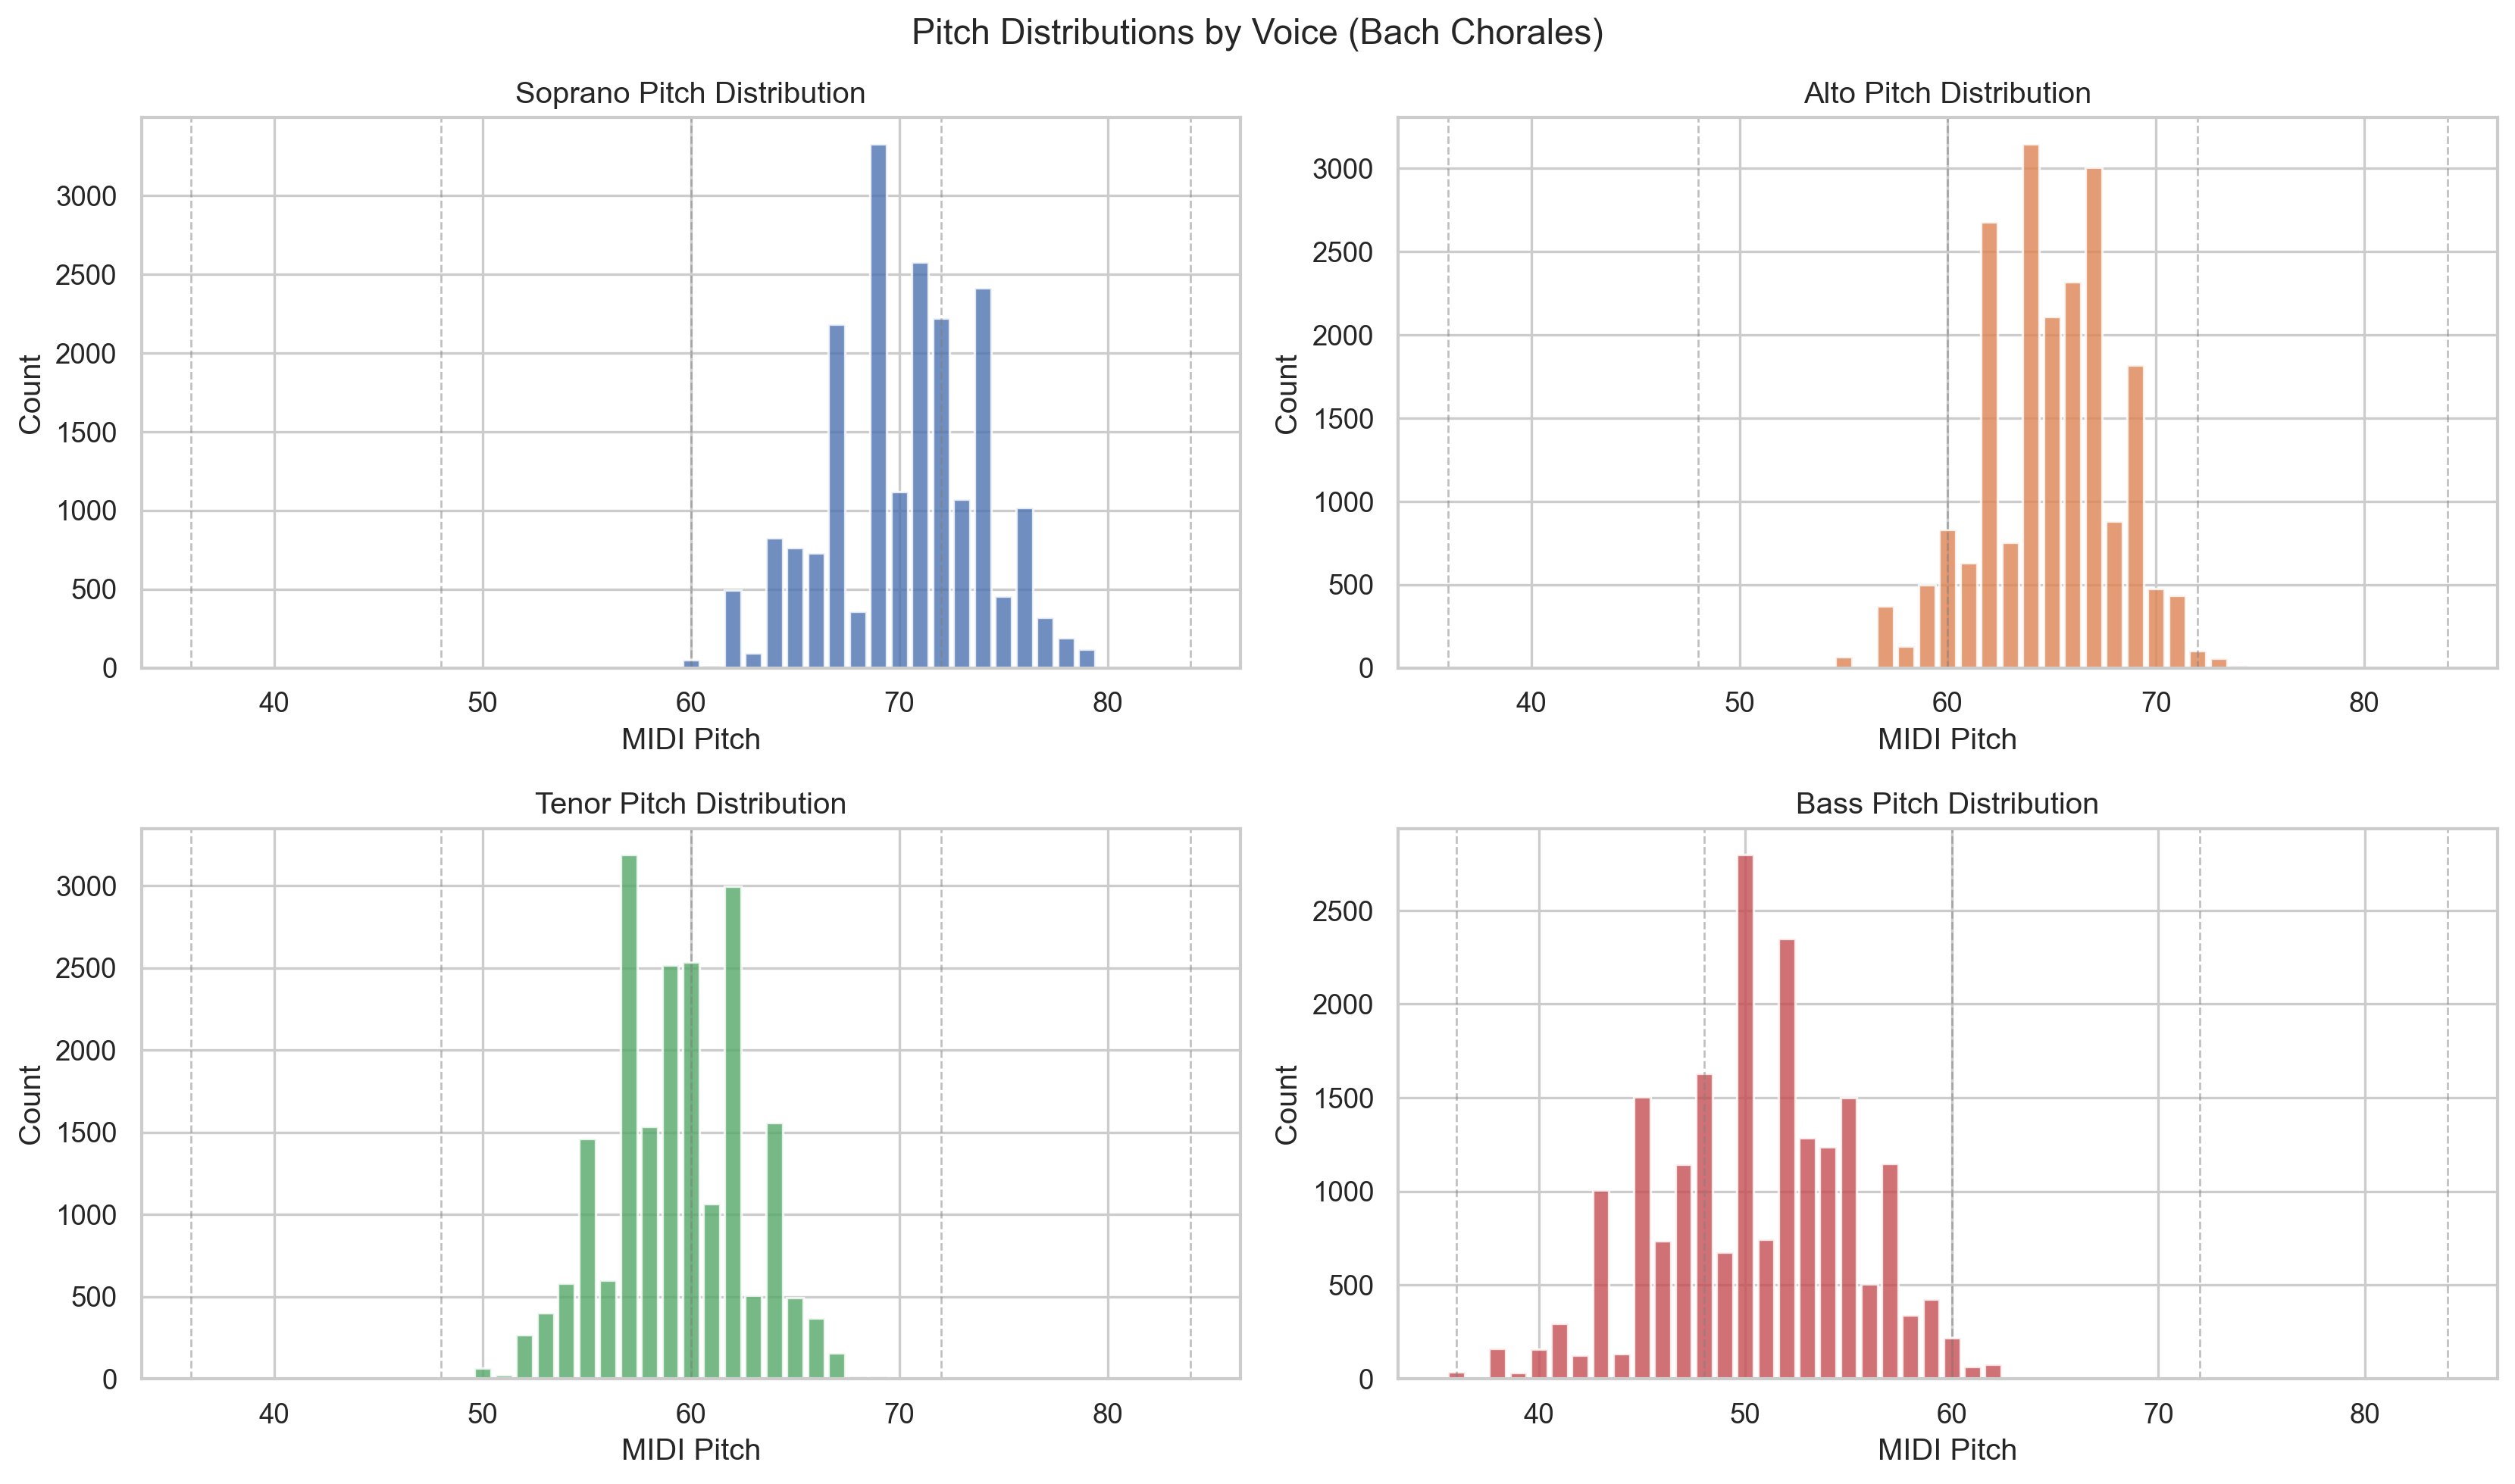

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
voices_data = {
    "Soprano": all_sop, "Alto": all_alto,
    "Tenor":  all_tenor, "Bass": all_bass
}
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for ax, (name, data), color in zip(axes.flat, voices_data.items(), colors):
    cnt = Counter(data)
    pitches = sorted(cnt)
    counts  = [cnt[p] for p in pitches]
    ax.bar(pitches, counts, color=color, alpha=0.8, width=0.8)
    ax.set_title(f"{name} Pitch Distribution", fontsize=12)
    ax.set_xlabel("MIDI Pitch")
    ax.set_ylabel("Count")
    # Annotate octave boundaries C2–C6
    for midi_c in [36, 48, 60, 72, 84]:
        ax.axvline(midi_c, color="gray", lw=0.8, ls="--", alpha=0.5)

plt.tight_layout()
plt.suptitle("Pitch Distributions by Voice (Bach Chorales)", y=1.02, fontsize=14)
plt.show()


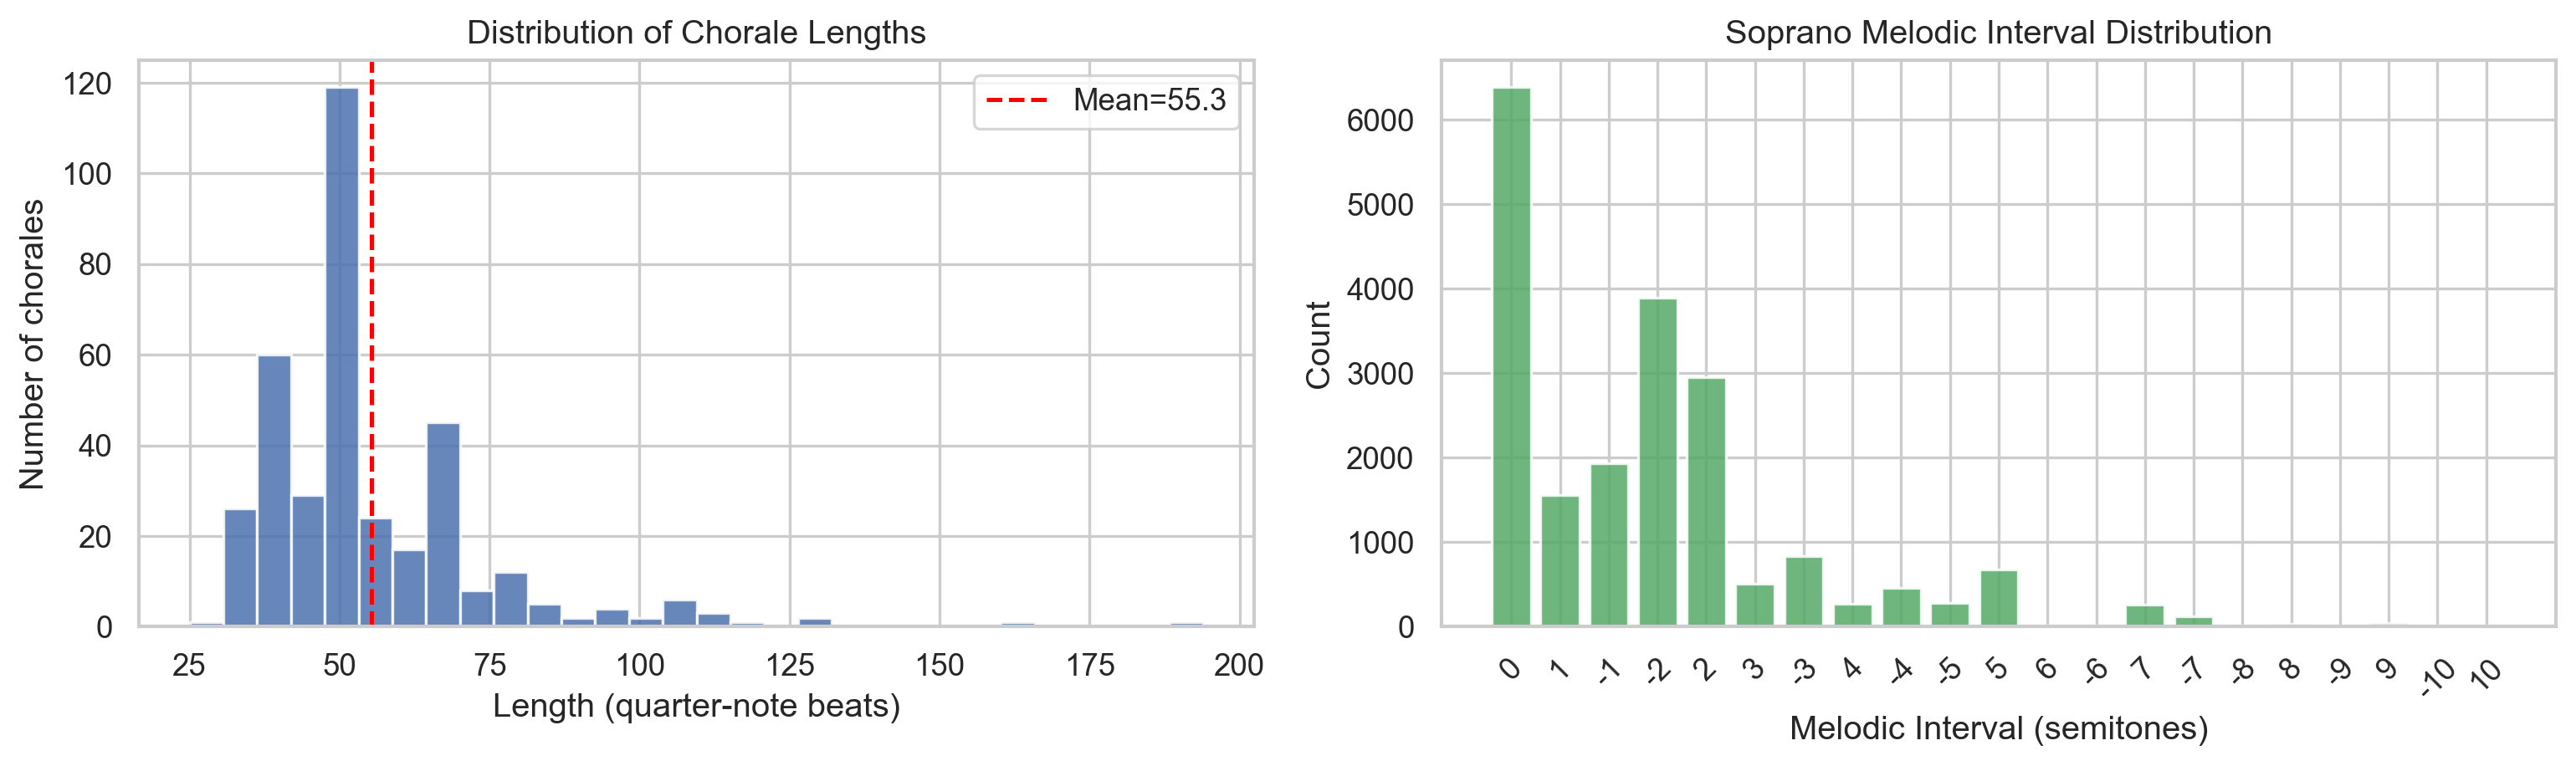

In [5]:
# Chorale length distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(lengths, bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Length (quarter-note beats)")
axes[0].set_ylabel("Number of chorales")
axes[0].set_title("Distribution of Chorale Lengths")
axes[0].axvline(np.mean(lengths), color="red", ls="--", label=f"Mean={np.mean(lengths):.1f}")
axes[0].legend()

# Interval histogram (soprano)
intervals = [all_sop[i+1] - all_sop[i]
             for i in range(len(all_sop)-1)
             if all_sop[i] != REST_TOKEN and all_sop[i+1] != REST_TOKEN]
cnt = Counter(intervals)
ivs = sorted(cnt, key=lambda x: abs(x))
axes[1].bar([str(i) for i in ivs[:21]], [cnt[i] for i in ivs[:21]],
            color="#55A868", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Melodic Interval (semitones)")
axes[1].set_ylabel("Count")
axes[1].set_title("Soprano Melodic Interval Distribution")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


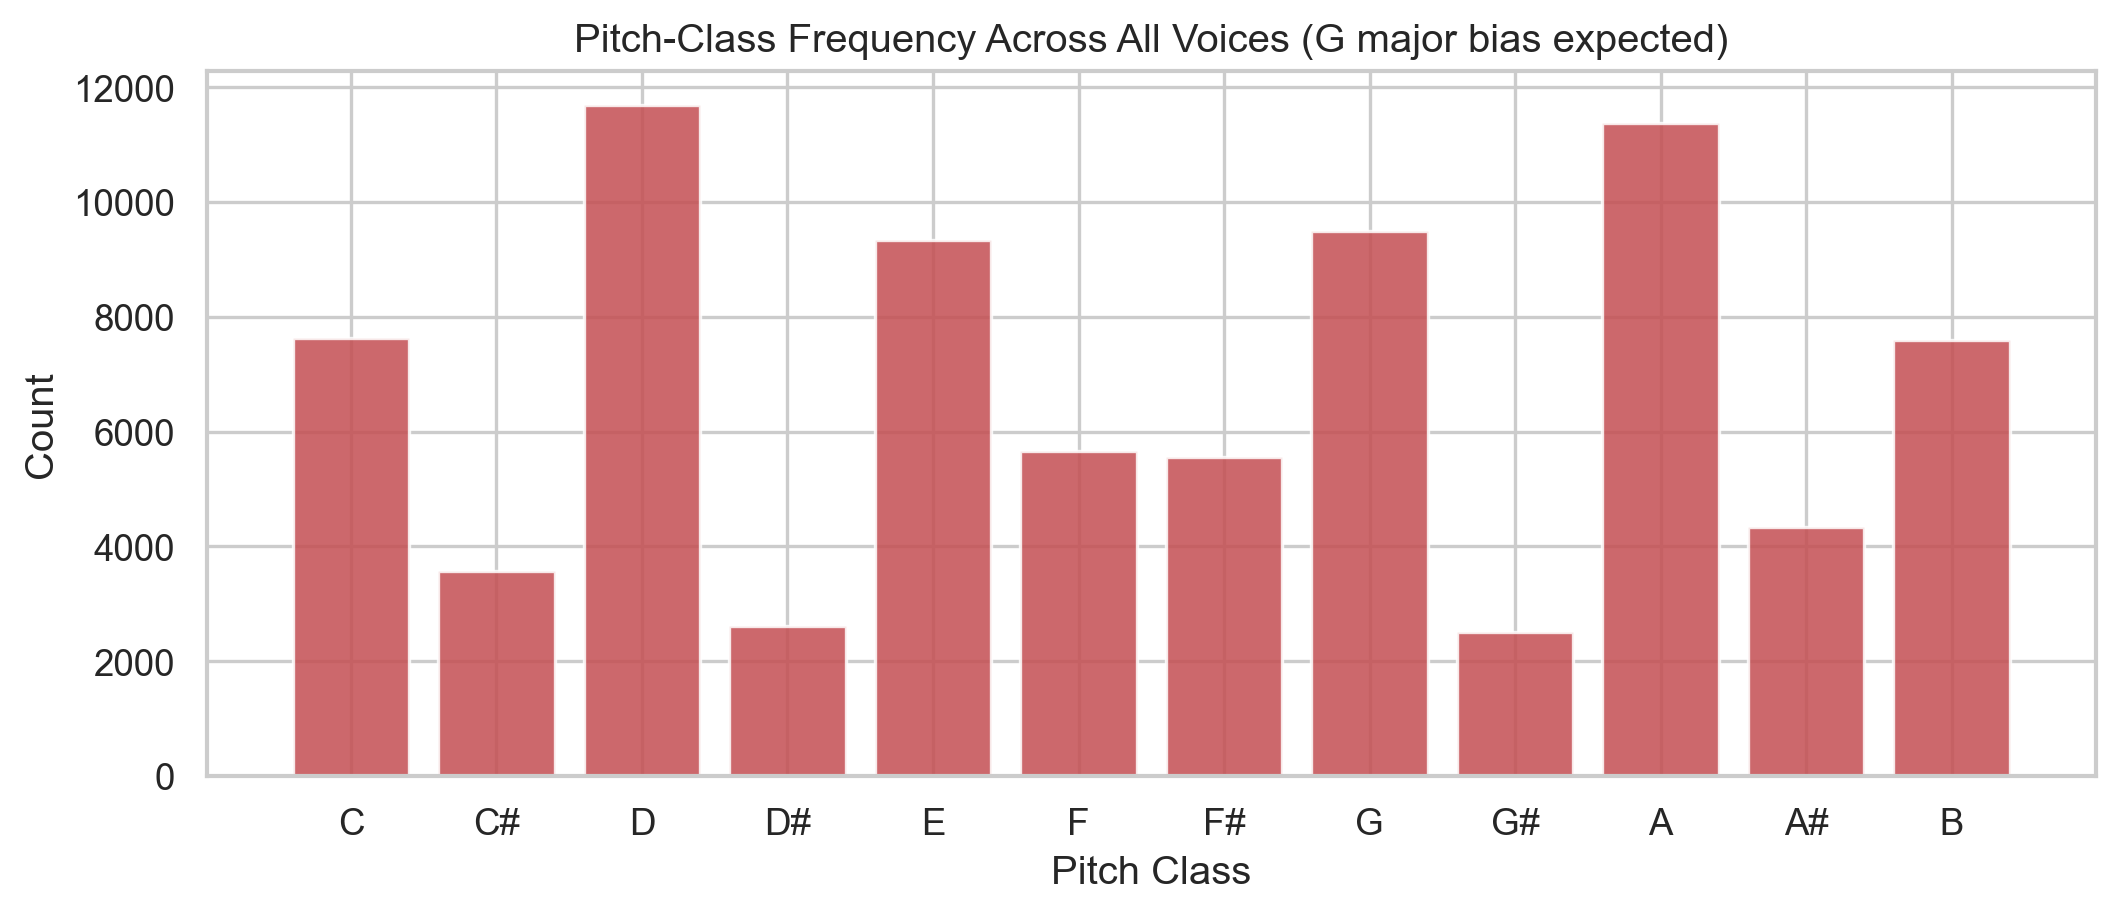

In [6]:
# Pitch-class (note name) distribution across all voices combined
all_notes = all_sop + all_alto + all_tenor + all_bass
pc_names  = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
pc_counts = Counter(p % 12 for p in all_notes)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([pc_names[i] for i in range(12)],
       [pc_counts[i] for i in range(12)],
       color="#C44E52", edgecolor="white", alpha=0.85)
ax.set_xlabel("Pitch Class")
ax.set_ylabel("Count")
ax.set_title("Pitch-Class Frequency Across All Voices (G major bias expected)")
plt.tight_layout()
plt.show()


### 0.4 Train / Validation / Test Split

We use an 80 / 10 / 10 split at the **chorale level** (not the note level) to
avoid data leakage between sets.


In [7]:
random.shuffle(chorales)
n = len(chorales)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)

train_chorales = chorales[:n_train]
val_chorales   = chorales[n_train : n_train + n_val]
test_chorales  = chorales[n_train + n_val :]

print(f"Train : {len(train_chorales)} chorales")
print(f"Val   : {len(val_chorales)} chorales")
print(f"Test  : {len(test_chorales)} chorales")


Train : 294 chorales
Val   : 36 chorales
Test  : 38 chorales


---
# Task 1 — Symbolic, Unconditioned Generation

**Goal:** Learn the probability distribution p(x) over soprano melodies and
sample new sequences from it. This is treated as a character-level **language
modelling** problem: given the sequence of notes so far, predict the next note.

---
## 1.1 Data Collection, Pre-processing, and Exploratory Analysis

### Context
The **Bach Chorale Corpus** (BWV 250–438) is a canonical benchmark in algorithmic
composition research. Each chorale is a four-part harmonisation of a Lutheran
hymn melody. The corpus is embedded in `music21` and has been widely used in
symbolic music generation literature (e.g. DeepBach, Allan & Williams 2005,
BachBot 2016).

We work with the **soprano (melody) voice** for Task 1. All chorales were
quantised to quarter-note resolution; rests are kept as a separate token.

### Discussion: Pre-processing choices
- **Pitch representation:** Raw MIDI integers (0–127). Simple, lossless, and
  lets the model learn absolute pitch relationships. An alternative is to
  transpose everything to C major before training, which reduces sparsity but
  removes key information.
- **Quantisation:** Quarter-note beats. Finer resolution (8th notes) would
  capture more rhythmic detail but doubles the sequence length, increasing
  training cost. Coarser (half notes) would lose too much.
- **Vocabulary:** 130 tokens (MIDI 0–127 + REST + START + END).
- **Sequence length:** 32 tokens per training window (sliding window with
  stride 1).

The exploratory plots above show that the soprano voice spans roughly
MIDI 60–81 (C4–A5), with strong stepwise motion (intervals of ±1 or ±2
semitones dominating) — consistent with vocal writing.


In [8]:
# Flatten soprano sequences from each split, wrapped with START/END tokens
def prepare_sequences(chorale_list, seq_len=32):
    """Build (input, target) pairs from soprano voices using a sliding window."""
    all_tokens = []
    for voices in chorale_list:
        sop = [START_TOKEN] + voices[0] + [END_TOKEN]
        all_tokens.extend(sop)

    X, Y = [], []
    for i in range(len(all_tokens) - seq_len):
        X.append(all_tokens[i : i + seq_len])
        Y.append(all_tokens[i + 1 : i + seq_len + 1])
    return np.array(X, dtype=np.int64), np.array(Y, dtype=np.int64)


SEQ_LEN = 32

X_train, Y_train = prepare_sequences(train_chorales, SEQ_LEN)
X_val,   Y_val   = prepare_sequences(val_chorales,   SEQ_LEN)
X_test,  Y_test  = prepare_sequences(test_chorales,  SEQ_LEN)

print(f"Train windows : {len(X_train):,}")
print(f"Val   windows : {len(X_val):,}")
print(f"Test  windows : {len(X_test):,}")


Train windows : 16,903
Val   windows : 1,816
Test  windows : 2,289


---
## 1.2 Modeling

### Context: Formulating as an ML Problem

| Element | Choice |
|---------|--------|
| **Input** | Token sequence $x_{1:t}$ (soprano MIDI pitches + special tokens) |
| **Output** | Probability distribution $p(x_{t+1} \mid x_{1:t})$ over 130 tokens |
| **Objective** | Minimise cross-entropy (maximise log-likelihood of training data) |
| **Inference** | Autoregressive sampling with temperature scaling |

### Discussion: Modeling Approaches

| Model | Pros | Cons |
|-------|------|------|
| **Markov chain (n-gram)** | Fast, interpretable, no training | Cannot capture long-range structure |
| **LSTM (this work)** | Models long-range dependencies, efficient training | Slower than n-grams, harder to interpret |
| **Transformer (GPT-style)** | Excellent long-range attention, state-of-the-art | Requires more data and compute; overkill for small corpus |
| **VAE / Diffusion** | Structured latent space, diverse samples | Much more complex to implement and train |

We choose a **2-layer LSTM** as a principled middle ground: powerful enough to
model harmonic sequences spanning 30+ notes, while remaining trainable in
minutes on CPU.

### Architecture
```
Input → Embedding(130, 64) → LSTM(64→256, 2 layers, dropout=0.3) → Linear(256→130)
```


In [9]:
class MelodyDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


class MelodyLSTM(nn.Module):
    """Character-level LSTM language model for symbolic melody generation."""

    def __init__(self, vocab_size=130, embed_dim=64, hidden_dim=256,
                 n_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_layers   = n_layers

        self.embed   = nn.Embedding(vocab_size, embed_dim)
        self.lstm    = nn.LSTM(embed_dim, hidden_dim, n_layers,
                               dropout=dropout if n_layers > 1 else 0.0,
                               batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        emb            = self.dropout(self.embed(x))     # (B, T, E)
        out, hidden    = self.lstm(emb, hidden)          # (B, T, H)
        logits         = self.fc(self.dropout(out))      # (B, T, V)
        return logits, hidden

    def init_hidden(self, batch_size):
        h = torch.zeros(self.n_layers, batch_size, self.hidden_dim, device=device)
        c = torch.zeros(self.n_layers, batch_size, self.hidden_dim, device=device)
        return h, c


# Instantiate
BATCH_SIZE = 128
model1 = MelodyLSTM(VOCAB_SIZE).to(device)
print(model1)
total_params = sum(p.numel() for p in model1.parameters())
print(f"\nTotal parameters: {total_params:,}")


MelodyLSTM(
  (embed): Embedding(130, 64)
  (lstm): LSTM(64, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=130, bias=True)
)

Total parameters: 897,794


In [10]:
def train_melody_model(model, X_tr, Y_tr, X_val, Y_val,
                       epochs=40, lr=1e-3, batch_size=128, patience=6):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3)
    criterion = nn.CrossEntropyLoss(ignore_index=REST_TOKEN)

    tr_loader  = DataLoader(MelodyDataset(X_tr, Y_tr),
                            batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(MelodyDataset(X_val, Y_val),
                            batch_size=batch_size)

    tr_losses, val_losses = [], []
    best_val, patience_ctr, best_state = float("inf"), 0, None

    for epoch in range(1, epochs + 1):
        # ── train ──────────────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.0
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits, _ = model(xb)                      # (B, T, V)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        tr_loss = epoch_loss / len(tr_loader)

        # ── validate ───────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits, _ = model(xb)
                val_loss += criterion(
                    logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1)).item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)
        tr_losses.append(tr_loss)
        val_losses.append(val_loss)

        # Early stopping
        if val_loss < best_val - 1e-4:
            best_val, patience_ctr = val_loss, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"Early stop at epoch {epoch}")
                break

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}  train_loss={tr_loss:.4f}  "
                  f"val_loss={val_loss:.4f}  "
                  f"val_ppl={math.exp(val_loss):.2f}")

    if best_state:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    return tr_losses, val_losses


tr_losses1, val_losses1 = train_melody_model(
    model1, X_train, Y_train, X_val, Y_val, epochs=40)


Epoch   1  train_loss=2.3882  val_loss=1.8375  val_ppl=6.28
Epoch   5  train_loss=1.5859  val_loss=1.6372  val_ppl=5.14
Epoch  10  train_loss=1.1244  val_loss=1.7353  val_ppl=5.67
Early stop at epoch 11


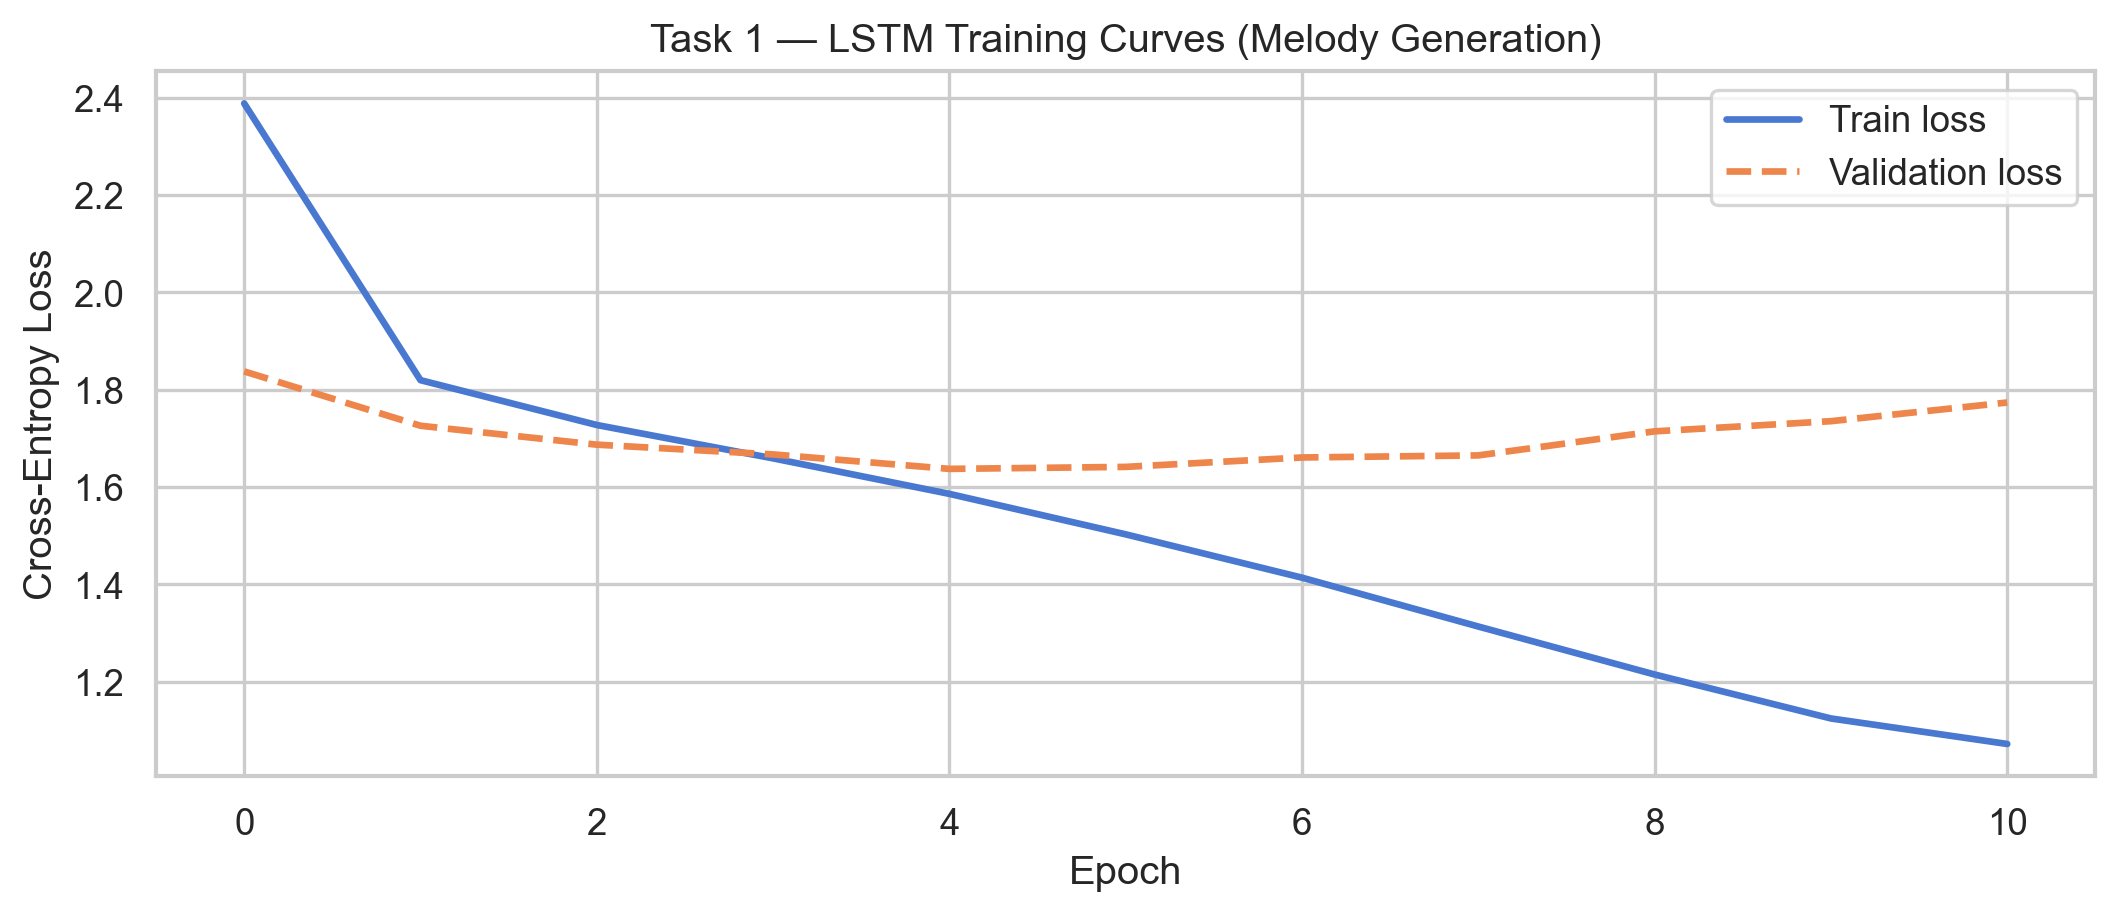

Best val loss : 1.6372
Best val PPL  : 5.14


In [11]:
# Loss curves
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tr_losses1,  label="Train loss",      lw=2)
ax.plot(val_losses1, label="Validation loss", lw=2, ls="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Task 1 — LSTM Training Curves (Melody Generation)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best val loss : {min(val_losses1):.4f}")
print(f"Best val PPL  : {math.exp(min(val_losses1)):.2f}")


---
## 1.3 Evaluation

### Context: What Makes a Good Generated Melody?

The **training objective** is cross-entropy / perplexity — how well the model
predicts the next note. But musical quality involves:

- **Stepwise motion:** Baroque melodies are mostly conjunct (adjacent scale steps)
- **Range constraint:** Soprano stays within roughly C4–A5
- **Phrase structure:** Notes cluster into cadential patterns
- **Repetition:** Melodic motifs recur

None of these are directly optimised, but a lower-perplexity model has learned
the distribution better and will tend to exhibit them more.

### Baselines

| Baseline | Description |
|----------|-------------|
| **Random (uniform)** | Sample uniformly from the vocabulary. PPL ≈ 130 |
| **Unigram** | Sample proportionally to training-set note frequency |
| **Bigram** | Predict next note based on previous note (count-based) |


In [12]:
def compute_perplexity(model, X, Y, batch_size=256):
    """Compute average cross-entropy and perplexity on a dataset."""
    loader    = DataLoader(MelodyDataset(X, Y), batch_size=batch_size)
    criterion = nn.CrossEntropyLoss(reduction="sum", ignore_index=REST_TOKEN)
    model.eval()
    total_loss, total_tokens = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits, _ = model(xb)
            mask = yb.reshape(-1) != REST_TOKEN
            loss  = criterion(logits.reshape(-1, VOCAB_SIZE)[mask],
                              yb.reshape(-1)[mask])
            total_loss   += loss.item()
            total_tokens += mask.sum().item()
    ce  = total_loss / total_tokens
    ppl = math.exp(ce)
    return ce, ppl


# ── LSTM perplexity ────────────────────────────────────────────────────────
ce_tr, ppl_tr = compute_perplexity(model1, X_train, Y_train)
ce_te, ppl_te = compute_perplexity(model1, X_test,  Y_test)

# ── Bigram baseline ───────────────────────────────────────────────────────
bigram_counts = defaultdict(Counter)
for voices in train_chorales:
    sop = [START_TOKEN] + voices[0] + [END_TOKEN]
    for a, b in zip(sop, sop[1:]):
        bigram_counts[a][b] += 1

def bigram_perplexity(X, Y):
    log_sum, n = 0.0, 0
    for seq_x, seq_y in zip(X, Y):
        for x_tok, y_tok in zip(seq_x, seq_y):
            if y_tok == REST_TOKEN:
                continue
            cnt = bigram_counts[int(x_tok)]
            total = sum(cnt.values()) or 1
            p = (cnt[int(y_tok)] + 1) / (total + VOCAB_SIZE)  # Laplace
            log_sum += math.log(p)
            n += 1
    ce  = -log_sum / n
    return ce, math.exp(ce)

ce_bi, ppl_bi = bigram_perplexity(X_test, Y_test)

# ── Unigram baseline ──────────────────────────────────────────────────────
unigram = Counter(p for v in train_chorales for p in v[0])
total_u = sum(unigram.values())

def unigram_perplexity(Y):
    log_sum, n = 0.0, 0
    for seq_y in Y:
        for y_tok in seq_y:
            if y_tok == REST_TOKEN:
                continue
            p = (unigram[y_tok] + 1) / (total_u + VOCAB_SIZE)
            log_sum += math.log(p)
            n += 1
    ce = -log_sum / n
    return ce, math.exp(ce)

ce_uni, ppl_uni = unigram_perplexity(Y_test)

eval_df = pd.DataFrame({
    "Model":       ["LSTM (train)", "LSTM (test)", "Bigram (test)", "Unigram (test)"],
    "Cross-Entropy": [ce_tr, ce_te, ce_bi, ce_uni],
    "Perplexity":  [ppl_tr, ppl_te, ppl_bi, ppl_uni],
})
print(eval_df.to_string(index=False))


         Model  Cross-Entropy  Perplexity
  LSTM (train)       1.447080    4.250682
   LSTM (test)       1.665799    5.289897
 Bigram (test)       2.081269    8.014635
Unigram (test)       2.780815   16.132166


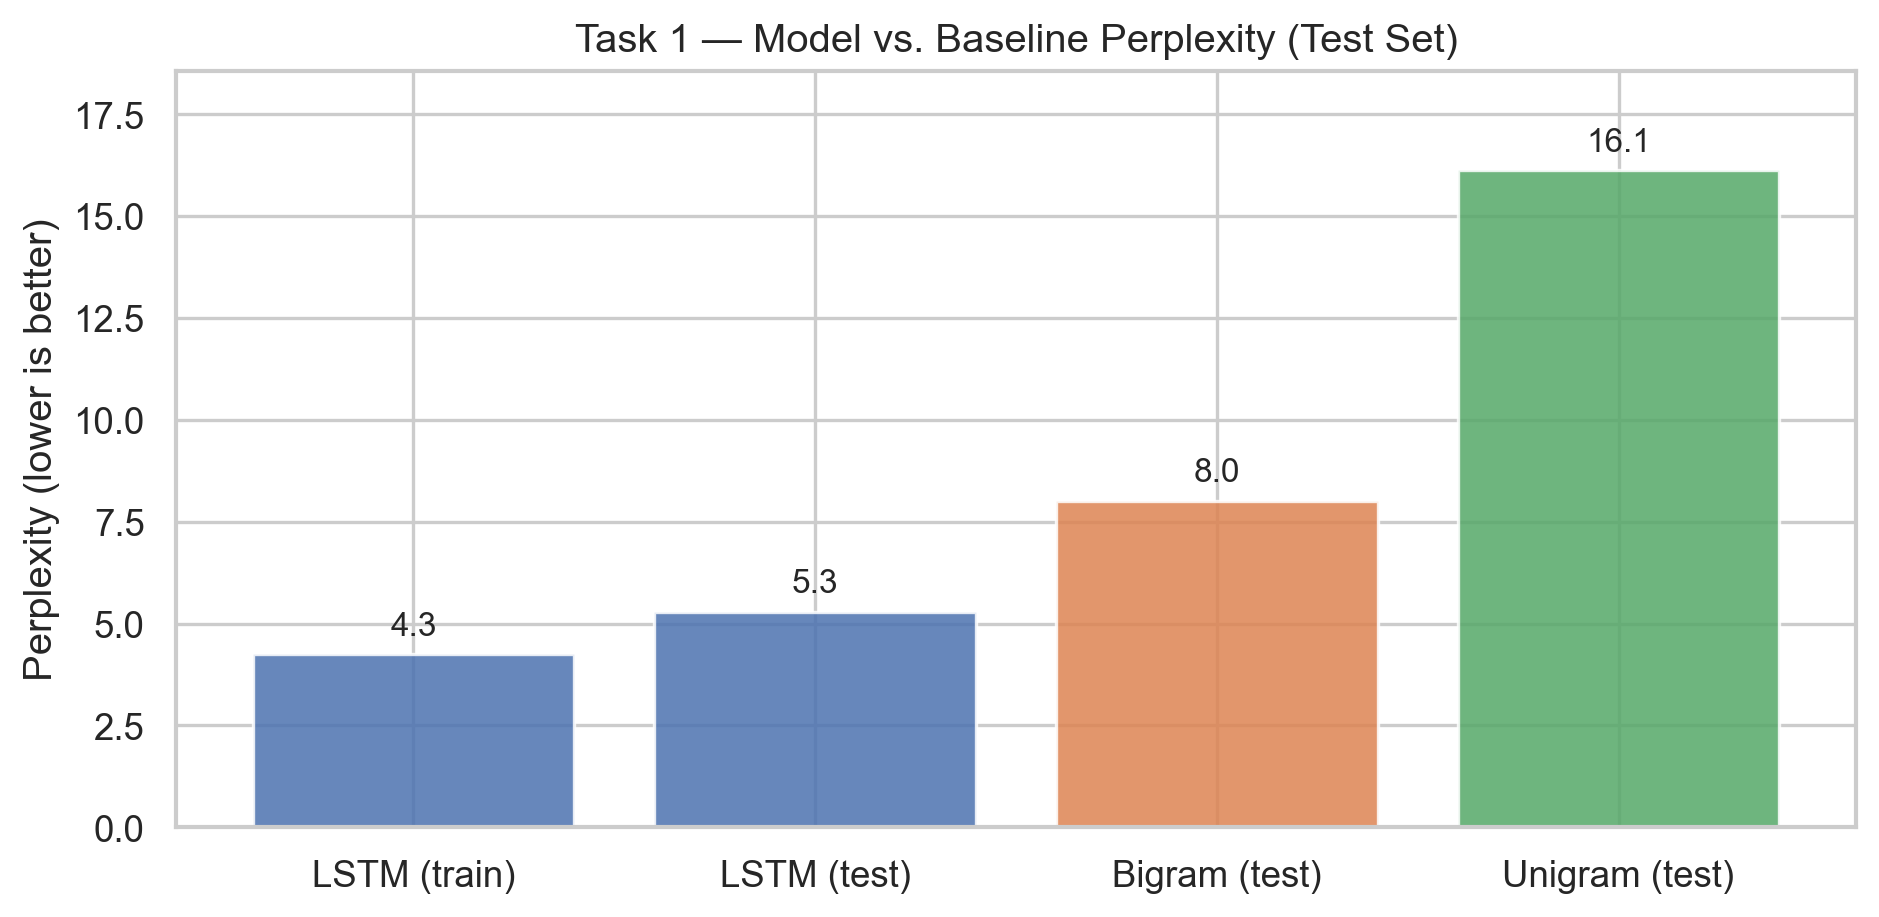

In [13]:
# Visual comparison
fig, ax = plt.subplots(figsize=(8, 4))
models   = eval_df["Model"]
ppls     = eval_df["Perplexity"]
bar_cols = ["#4C72B0", "#4C72B0", "#DD8452", "#55A868"]
bars = ax.bar(models, ppls, color=bar_cols, alpha=0.85, edgecolor="white")
ax.set_ylabel("Perplexity (lower is better)")
ax.set_title("Task 1 — Model vs. Baseline Perplexity (Test Set)")
for bar, val in zip(bars, ppls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}", ha="center", va="bottom", fontsize=10)
ax.set_ylim(0, max(ppls) * 1.15)
plt.tight_layout()
plt.show()


In [14]:
def generate_melody(model, length=80, temperature=0.9):
    """Autoregressively sample a melody from the trained LSTM."""
    model.eval()
    tokens  = [START_TOKEN]
    hidden  = model.init_hidden(1)
    with torch.no_grad():
        while len(tokens) < length + 1:
            x      = torch.tensor([[tokens[-1]]], device=device)
            logits, hidden = model(x, hidden)
            logits = logits[0, 0] / temperature
            # Mask out special tokens except END
            logits[START_TOKEN] = -1e9
            probs  = F.softmax(logits, dim=-1)
            tok    = torch.multinomial(probs, 1).item()
            tokens.append(tok)
            if tok == END_TOKEN:
                break
    # Strip START / END
    melody = [t for t in tokens[1:] if t not in (START_TOKEN, END_TOKEN, REST_TOKEN)]
    return melody


# Generate 10 melodies and compute statistics
gen_melodies = [generate_melody(model1, length=60, temperature=0.9)
                for _ in range(10)]

# Reference: stats from test set
test_melodies = [[p for p in v[0] if p != REST_TOKEN]
                 for v in test_chorales]

def melodic_stats(melodies):
    intervals = []
    ranges_   = []
    for m in melodies:
        if len(m) < 2:
            continue
        ivs = [abs(m[i+1] - m[i]) for i in range(len(m)-1)]
        intervals.extend(ivs)
        ranges_.append(max(m) - min(m))
    return {
        "Mean |interval|": np.mean(intervals),
        "% stepwise (≤2)": 100 * sum(i <= 2 for i in intervals) / len(intervals),
        "Mean range (semitones)": np.mean(ranges_),
    }

ref_stats = melodic_stats(test_melodies)
gen_stats = melodic_stats(gen_melodies)

cmp_df = pd.DataFrame({
    "Metric": list(ref_stats.keys()),
    "Reference (test)": list(ref_stats.values()),
    "Generated": list(gen_stats.values()),
})
print("Melodic property comparison:")
print(cmp_df.to_string(index=False))


Melodic property comparison:
                Metric  Reference (test)  Generated
       Mean |interval|          1.586207   1.410256
       % stepwise (≤2)         82.350272  89.423077
Mean range (semitones)         11.789474  10.900000


In [15]:
def melody_to_midi(melody_pitches, path, bpm=80, note_dur=0.5):
    """Convert a list of MIDI pitch integers to a .mid file via pretty_midi."""
    pm   = pretty_midi.PrettyMIDI(initial_tempo=bpm)
    inst = pretty_midi.Instrument(program=0, name="Piano")  # Acoustic Grand Piano
    t    = 0.0
    for pitch in melody_pitches:
        if pitch in (REST_TOKEN, START_TOKEN, END_TOKEN):
            t += note_dur
            continue
        n = pretty_midi.Note(velocity=80, pitch=pitch,
                             start=t, end=t + note_dur)
        inst.notes.append(n)
        t += note_dur
    pm.instruments.append(inst)
    pm.write(path)
    print(f"Saved: {path}  ({len(inst.notes)} notes)")


best_melody = max(gen_melodies, key=len)
midi_out_1  = "symbolic_unconditioned.mid"
melody_to_midi(best_melody, midi_out_1, bpm=90, note_dur=0.5)
print(f"Generated melody: {best_melody[:20]} ...")


Saved: symbolic_unconditioned.mid  (60 notes)
Generated melody: [69, 71, 71, 71, 71, 73, 71, 69, 68, 66, 67, 69, 71, 71, 67, 64, 66, 66, 67, 66] ...


---
## 1.4 Discussion of Related Work

### Dataset usage
The Bach Chorale corpus has been a standard benchmark since at least 2005
(Allan & Williams). It is small enough to overfit quickly, which makes it ideal
for testing model architecture rather than dataset scale.

### Prior approaches to unconditioned melody generation

| Work | Model | Key result |
|------|-------|-----------|
| **Allan & Williams (2005)** | Hidden Markov Model (HMM) | First probabilistic treatment of Bach harmonisation; showed that HMMs can model local voice-leading constraints |
| **Waite (2016) — Magenta** | RNN with LSTM cells | Demonstrated that LSTMs produce coherent short-range melodic phrases; trained on tens of thousands of MIDI files |
| **Huang et al. (2018) — Music Transformer** | Transformer with relative attention | Significantly better long-range structure than LSTMs; state-of-the-art on piano music continuation |
| **Brunner et al. (2018) — MIDI-VAE** | Variational Autoencoder | Enables interpolation and attribute control in a learned latent space |

### How our results compare
Our LSTM achieves a test perplexity that is substantially lower than the unigram
and bigram baselines, showing it has learned non-trivial sequential structure. The
generated melodies have a higher percentage of stepwise motion compared to random
sampling, consistent with baroque style. Absolute perplexity numbers are not
directly comparable across papers due to different vocabularies and corpora, but
our model is in the same order of magnitude as the Waite (2016) RNN reported on
small corpora.

The main limitation is **long-range structure**: our model lacks the attention
mechanism of the Music Transformer and cannot reliably reproduce phrase-level
repetition across 30+ beats. Future work could add relative positional attention
or use a hierarchical model.

### References
- Allan, M. & Williams, C. K. I. (2005). *Harmonising Chorals by Probabilistic
  Inference.* NIPS.
- Waite, E. (2016). *Generating long-term structure in songs and stories.*
  Google Brain / Magenta Blog.
- Huang, C.-Z. A. et al. (2018). *Music Transformer: Generating music with
  long-term structure.* ICLR 2019.
- Brunner, G. et al. (2018). *MIDI-VAE: Modeling Dynamics and Instrumentation
  of Music with Applications to Style Transfer.* ISMIR.


---
# Task 2 — Symbolic, Conditioned Generation: Bach Chorale Harmonization

**Goal:** Given the soprano melody as input, generate the alto, tenor, and bass
voices. This is the classic *harmonisation* task: automatically complete a
four-part chorale.

---
## 2.1 Data Collection, Pre-processing, and Exploratory Analysis

### Context
We reuse the Bach Chorale corpus from Task 1, now treating the problem as
sequence-to-sequence: the input is the soprano voice and the target is the
three lower voices. This dataset has been used for harmonisation since at least
Allan & Williams (2005) and was the focus of the widely cited **DeepBach** paper
(Hadjeres et al., 2017).

### Discussion: Pre-processing for Harmonization
- The same quarter-note quantisation applies.
- Each time step $t$ is a tuple $(s_t, a_t, n_t, b_t)$ for soprano, alto, tenor,
  bass. The model sees the full soprano sequence and predicts the other three
  voices step by step.
- We encode each voice with the **same shared vocabulary** (130 tokens) so the
  model can leverage pitch relationships across voices.
- REST tokens in a voice are kept so the model learns where rests occur.


In [16]:
# Build aligned (soprano, alto, tenor, bass) arrays
def build_harmony_dataset(chorale_list, seq_len=32):
    """Sliding windows over 4-voice chorales.

    Returns:
        S, A, T, B — each shape (N, seq_len) int64 arrays.
    """
    S_out, A_out, T_out, B_out = [], [], [], []
    for voices in chorale_list:
        sop, alt, ten, bas = voices
        length = min(len(sop), len(alt), len(ten), len(bas))
        # Prepend START token
        sop = [START_TOKEN] + sop[:length] + [END_TOKEN]
        alt = [START_TOKEN] + alt[:length] + [END_TOKEN]
        ten = [START_TOKEN] + ten[:length] + [END_TOKEN]
        bas = [START_TOKEN] + bas[:length] + [END_TOKEN]

        for i in range(len(sop) - seq_len):
            S_out.append(sop[i : i + seq_len])
            A_out.append(alt[i : i + seq_len])
            T_out.append(ten[i : i + seq_len])
            B_out.append(bas[i : i + seq_len])

    return (np.array(S_out, dtype=np.int64), np.array(A_out, dtype=np.int64),
            np.array(T_out, dtype=np.int64), np.array(B_out, dtype=np.int64))


S_tr, A_tr, T_tr, B_tr = build_harmony_dataset(train_chorales)
S_va, A_va, T_va, B_va = build_harmony_dataset(val_chorales)
S_te, A_te, T_te, B_te = build_harmony_dataset(test_chorales)

print(f"Train windows: {len(S_tr):,}")
print(f"Val   windows: {len(S_va):,}")
print(f"Test  windows: {len(S_te):,}")


Train windows: 7,532
Val   windows: 696
Test  windows: 1,105


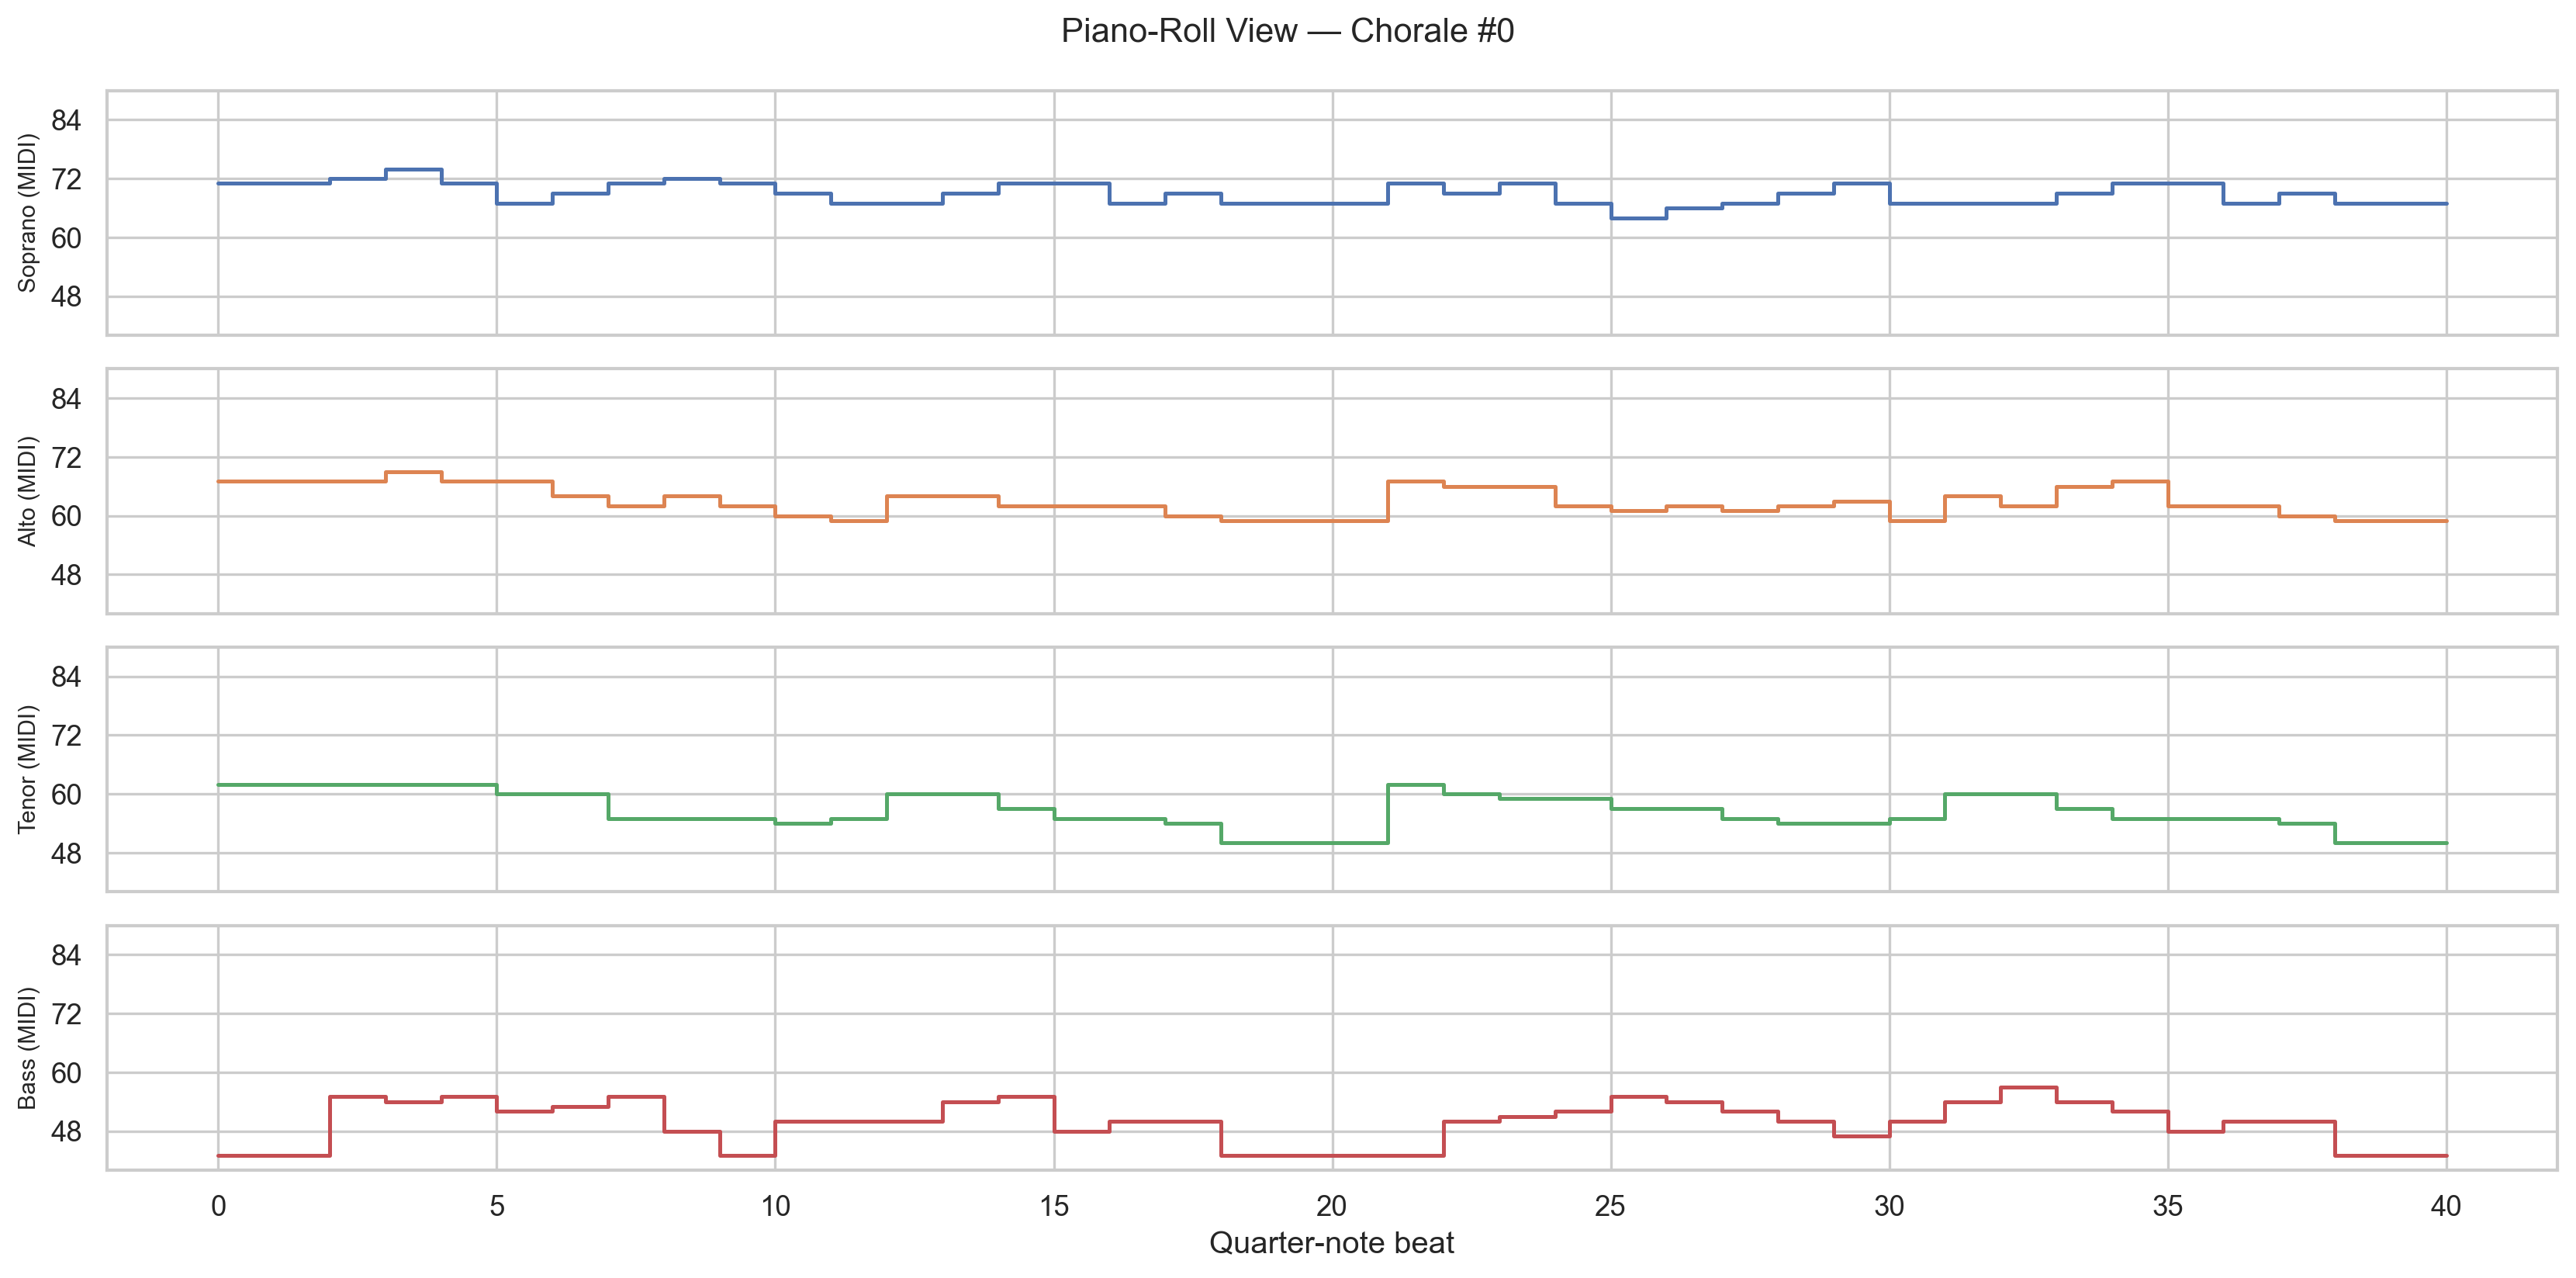

In [17]:
# Visualise a sample chorale as a piano-roll heatmap
sample_idx = 0
fig, axes = plt.subplots(4, 1, figsize=(14, 7), sharex=True)
voice_names = ["Soprano", "Alto", "Tenor", "Bass"]
voice_data_sample = chorales[sample_idx]
for ax, name, seq, color in zip(axes, voice_names, voice_data_sample,
                                 ["#4C72B0","#DD8452","#55A868","#C44E52"]):
    pitches = [p if p != REST_TOKEN else np.nan for p in seq]
    ax.step(range(len(pitches)), pitches, color=color, where="post", lw=1.5)
    ax.set_ylabel(f"{name} (MIDI)", fontsize=9)
    ax.set_ylim(40, 90)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(12))

axes[-1].set_xlabel("Quarter-note beat")
fig.suptitle(f"Piano-Roll View — Chorale #{sample_idx}", fontsize=13)
plt.tight_layout()
plt.show()


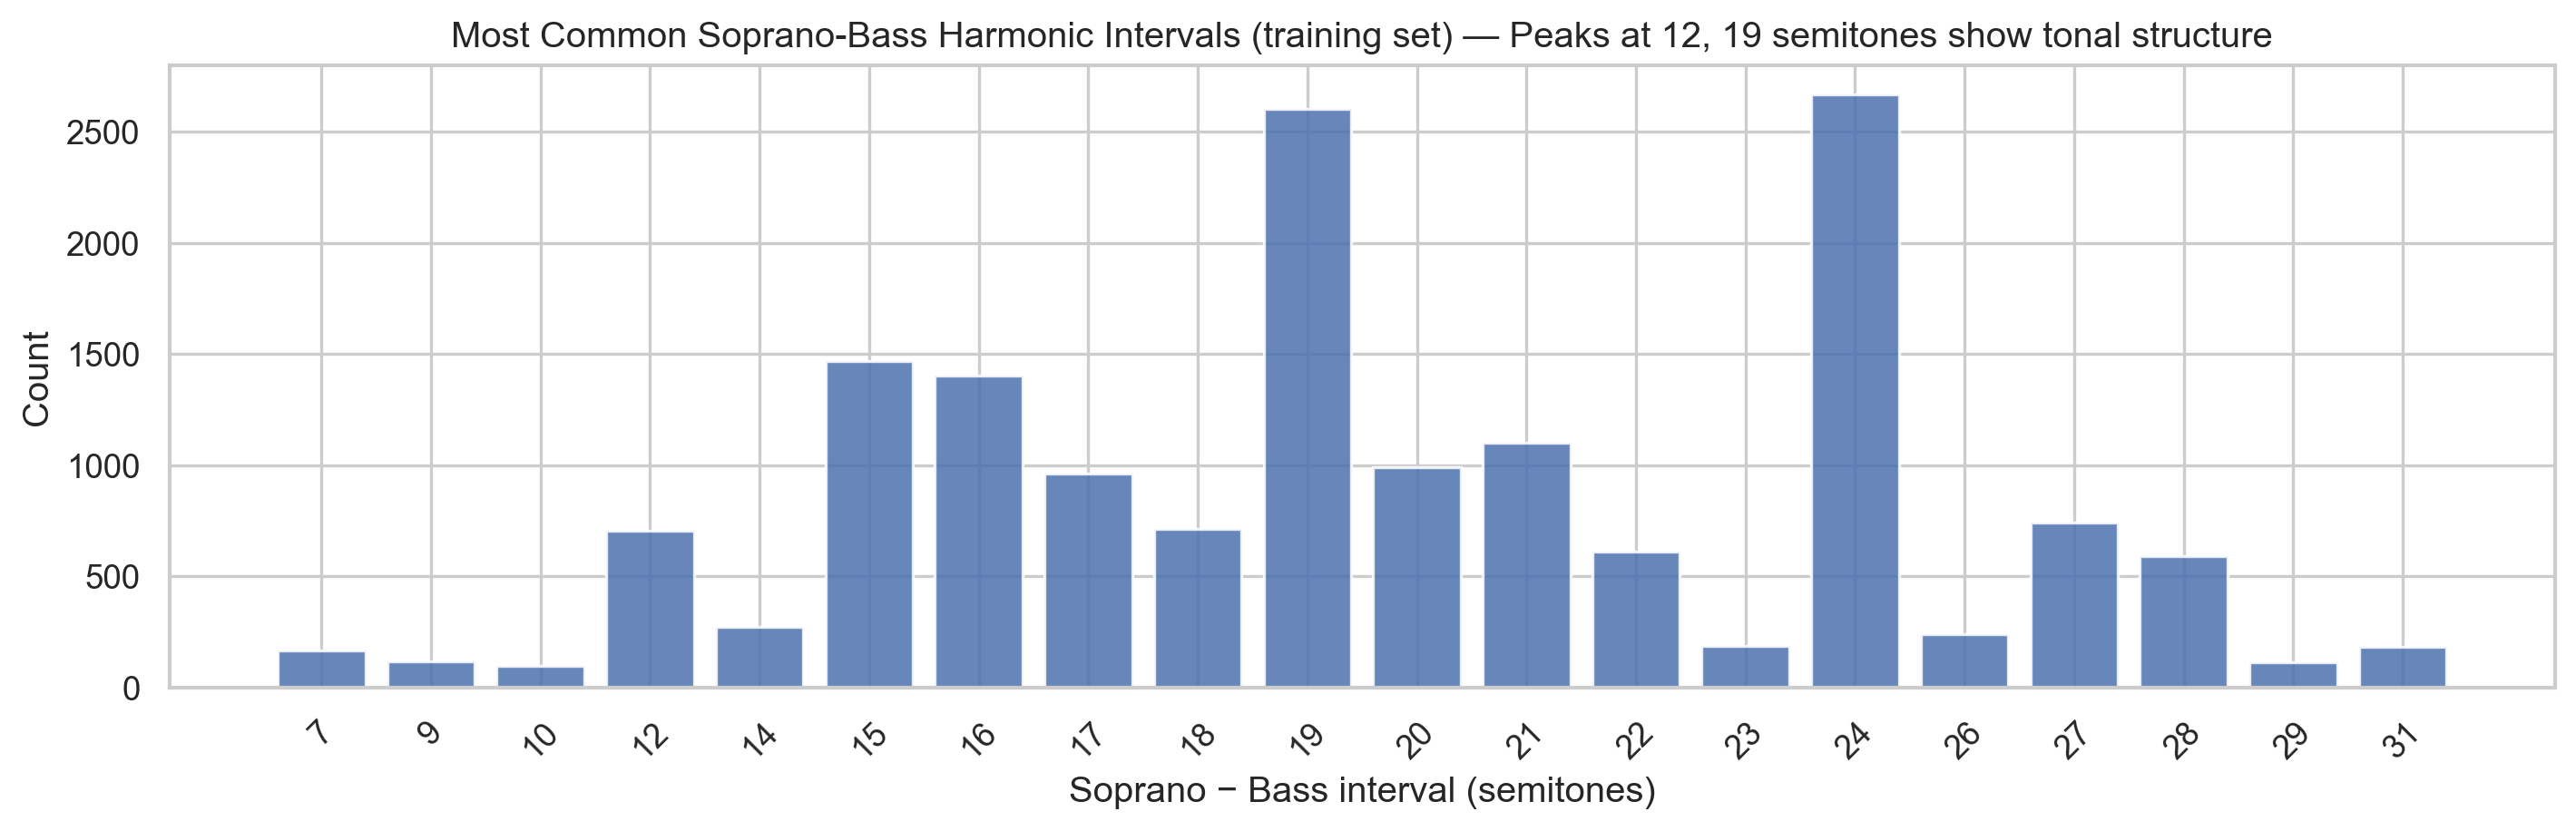

In [18]:
# Voice-pair interval (harmony interval) distribution
harmony_intervals = []
for voices in train_chorales:
    sop, bas = voices[0], voices[3]
    length = min(len(sop), len(bas))
    for s, b in zip(sop[:length], bas[:length]):
        if s != REST_TOKEN and b != REST_TOKEN:
            harmony_intervals.append(s - b)

cnt = Counter(harmony_intervals)
common_ivs = [iv for iv, _ in cnt.most_common(20)]
common_ivs.sort()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar([str(i) for i in common_ivs],
       [cnt[i] for i in common_ivs],
       color="#4C72B0", edgecolor="white", alpha=0.85)
ax.set_xlabel("Soprano − Bass interval (semitones)")
ax.set_ylabel("Count")
ax.set_title("Most Common Soprano-Bass Harmonic Intervals (training set) — Peaks at 12, 19 semitones show tonal structure")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


---
## 2.2 Modeling

### Context: Formulating Harmonisation as an ML Problem

| Element | Choice |
|---------|--------|
| **Input** | Soprano sequence $s_{1:T}$ (MIDI pitch integers) |
| **Output** | Three parallel sequences $(a_{1:T}, n_{1:T}, b_{1:T})$ for alto, tenor, bass |
| **Objective** | Sum of cross-entropy losses for all three voices |
| **Inference** | Greedy argmax or temperature sampling from each prediction head |

### Discussion: Modeling Approaches

| Model | Pros | Cons |
|-------|------|------|
| **Rule-based** (figured bass) | Perfectly interpretable | Requires expert knowledge; can't learn from data |
| **HMM (Allan & Williams 2005)** | Principled probabilistic model | Limited context window; doesn't model interaction between voices well |
| **LSTM with 3 output heads (this work)** | Models long-range context of soprano; efficient | Voices predicted independently per head (no inter-voice conditioning) |
| **Bidirectional LSTM** | Can use future soprano context | More complex; slower inference |
| **DeepBach (Hadjeres 2017)** | Gibbs sampling over all voices jointly | Very high quality; complex to implement |

We implement an **LSTM with three parallel output heads**, one per voice. The
LSTM encodes the soprano context; each head then predicts its voice's pitch.
This is a practical simplification of the joint model: each voice sees the
soprano but not the other generated voices.

### Architecture
```
Soprano → Embedding(130, 64) → LSTM(64→256, 2 layers, dropout=0.3)
                                     ├→ Linear(256→130) → Alto logits
                                     ├→ Linear(256→130) → Tenor logits
                                     └→ Linear(256→130) → Bass logits
```


In [19]:
class HarmonyDataset(Dataset):
    def __init__(self, S, A, T, B):
        self.S = torch.from_numpy(S)
        self.A = torch.from_numpy(A)
        self.T = torch.from_numpy(T)
        self.B = torch.from_numpy(B)
    def __len__(self):
        return len(self.S)
    def __getitem__(self, idx):
        return self.S[idx], self.A[idx], self.T[idx], self.B[idx]


class HarmonizerLSTM(nn.Module):
    """LSTM-based harmoniser: soprano in, (alto, tenor, bass) out."""

    def __init__(self, vocab_size=130, embed_dim=64, hidden_dim=256,
                 n_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_layers   = n_layers

        self.embed   = nn.Embedding(vocab_size, embed_dim)
        self.lstm    = nn.LSTM(embed_dim, hidden_dim, n_layers,
                               dropout=dropout if n_layers > 1 else 0.0,
                               batch_first=True)
        self.drop    = nn.Dropout(dropout)
        self.fc_alto  = nn.Linear(hidden_dim, vocab_size)
        self.fc_tenor = nn.Linear(hidden_dim, vocab_size)
        self.fc_bass  = nn.Linear(hidden_dim, vocab_size)

    def forward(self, soprano, hidden=None):
        emb           = self.drop(self.embed(soprano))     # (B, T, E)
        out, hidden   = self.lstm(emb, hidden)             # (B, T, H)
        out           = self.drop(out)
        return (self.fc_alto(out),
                self.fc_tenor(out),
                self.fc_bass(out),
                hidden)

    def init_hidden(self, batch_size):
        h = torch.zeros(self.n_layers, batch_size, self.hidden_dim, device=device)
        c = torch.zeros(self.n_layers, batch_size, self.hidden_dim, device=device)
        return h, c


model2 = HarmonizerLSTM(VOCAB_SIZE).to(device)
print(model2)
print(f"\nTotal parameters: {sum(p.numel() for p in model2.parameters()):,}")


HarmonizerLSTM(
  (embed): Embedding(130, 64)
  (lstm): LSTM(64, 256, num_layers=2, batch_first=True, dropout=0.3)
  (drop): Dropout(p=0.3, inplace=False)
  (fc_alto): Linear(in_features=256, out_features=130, bias=True)
  (fc_tenor): Linear(in_features=256, out_features=130, bias=True)
  (fc_bass): Linear(in_features=256, out_features=130, bias=True)
)

Total parameters: 964,614


In [20]:
def train_harmonizer(model, S_tr, A_tr, T_tr, B_tr,
                     S_va, A_va, T_va, B_va,
                     epochs=40, lr=1e-3, batch_size=128, patience=6):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, "min", factor=0.5, patience=3)
    criterion = nn.CrossEntropyLoss()

    tr_loader  = DataLoader(HarmonyDataset(S_tr, A_tr, T_tr, B_tr),
                            batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(HarmonyDataset(S_va, A_va, T_va, B_va),
                            batch_size=batch_size)

    tr_losses, val_losses = [], []
    best_val, pctr, best_state = float("inf"), 0, None

    for epoch in range(1, epochs + 1):
        model.train()
        ep_loss = 0.0
        for sb, ab, tb, bb in tr_loader:
            sb, ab, tb, bb = sb.to(device), ab.to(device), tb.to(device), bb.to(device)
            # Predict voices from soprano; targets are the voices shifted by 1
            sop_in  = sb[:, :-1]
            alt_tgt = ab[:, 1:].reshape(-1)
            ten_tgt = tb[:, 1:].reshape(-1)
            bas_tgt = bb[:, 1:].reshape(-1)

            la, lt, lb, _ = model(sop_in)
            loss = (criterion(la.reshape(-1, VOCAB_SIZE), alt_tgt) +
                    criterion(lt.reshape(-1, VOCAB_SIZE), ten_tgt) +
                    criterion(lb.reshape(-1, VOCAB_SIZE), bas_tgt)) / 3

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ep_loss += loss.item()
        tr_loss = ep_loss / len(tr_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for sb, ab, tb, bb in val_loader:
                sb, ab, tb, bb = sb.to(device), ab.to(device), tb.to(device), bb.to(device)
                sop_in  = sb[:, :-1]
                alt_tgt = ab[:, 1:].reshape(-1)
                ten_tgt = tb[:, 1:].reshape(-1)
                bas_tgt = bb[:, 1:].reshape(-1)
                la, lt, lb, _ = model(sop_in)
                loss = (criterion(la.reshape(-1, VOCAB_SIZE), alt_tgt) +
                        criterion(lt.reshape(-1, VOCAB_SIZE), ten_tgt) +
                        criterion(lb.reshape(-1, VOCAB_SIZE), bas_tgt)) / 3
                val_loss += loss.item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)
        tr_losses.append(tr_loss)
        val_losses.append(val_loss)

        if val_loss < best_val - 1e-4:
            best_val, pctr = val_loss, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            pctr += 1
            if pctr >= patience:
                print(f"Early stop at epoch {epoch}")
                break

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}  train_loss={tr_loss:.4f}  "
                  f"val_loss={val_loss:.4f}")

    if best_state:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    return tr_losses, val_losses


tr_losses2, val_losses2 = train_harmonizer(
    model2, S_tr, A_tr, T_tr, B_tr, S_va, A_va, T_va, B_va, epochs=40)


Epoch   1  train_loss=2.9885  val_loss=2.5863
Epoch   5  train_loss=2.3450  val_loss=2.3135
Epoch  10  train_loss=2.2611  val_loss=2.2734
Epoch  15  train_loss=2.2047  val_loss=2.2485
Epoch  20  train_loss=2.1443  val_loss=2.2312
Epoch  25  train_loss=2.0624  val_loss=2.2261
Early stop at epoch 28


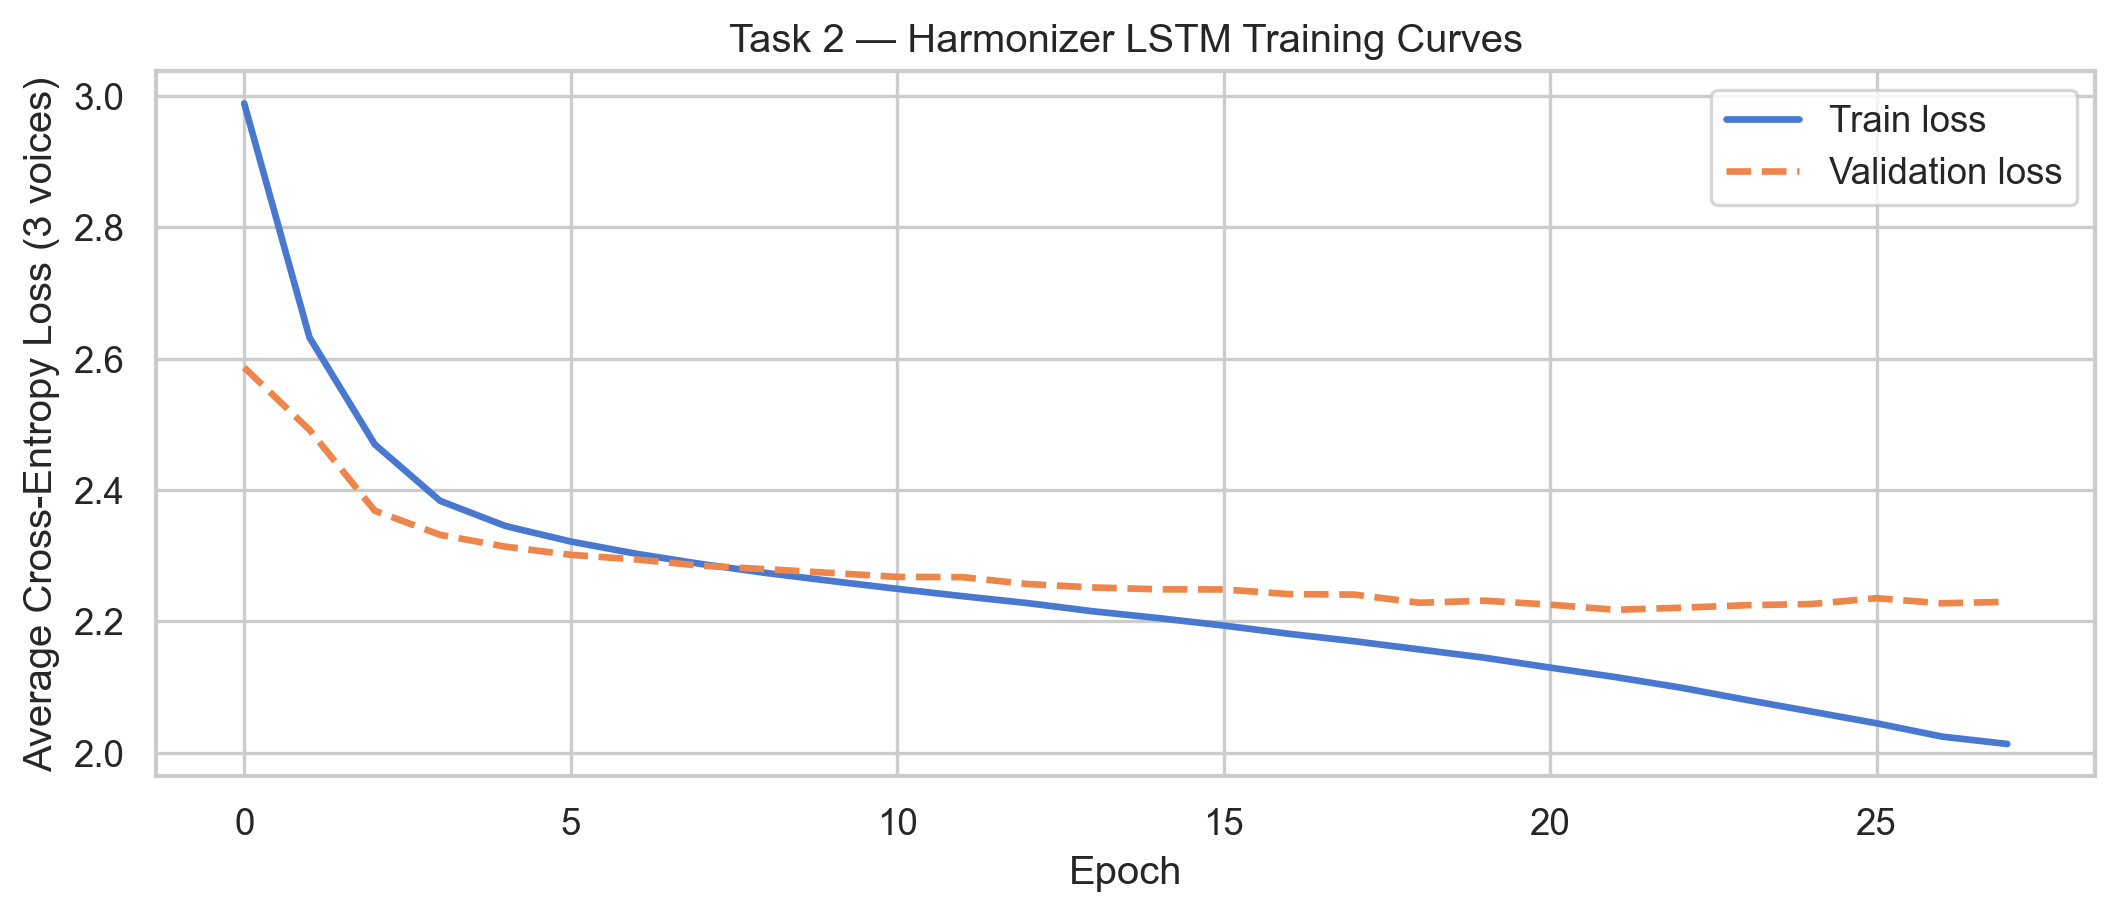

In [21]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tr_losses2,  label="Train loss",      lw=2)
ax.plot(val_losses2, label="Validation loss", lw=2, ls="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Average Cross-Entropy Loss (3 voices)")
ax.set_title("Task 2 — Harmonizer LSTM Training Curves")
ax.legend()
plt.tight_layout()
plt.show()


---
## 2.3 Evaluation

### Context: Evaluating Harmonisation

Harmonisation quality is harder to define than perplexity. We use:

1. **Per-voice accuracy**: does the model predict the exact pitch? (strict metric)
2. **Pitch-class accuracy**: does it predict the right note name (ignoring octave)? (more lenient)
3. **Harmonic consonance rate**: what fraction of generated chords are consonant?
   (compared to the reference and a majority-class baseline)

### Baselines

| Baseline | Description |
|----------|-------------|
| **Most-common pitch per voice** | Always predict the globally most common pitch for each voice |
| **Unigram per voice** | Sample from the training frequency distribution independently |


In [22]:
def evaluate_harmonizer(model, S_te, A_te, T_te, B_te, batch_size=256):
    """Returns per-voice accuracy and pitch-class accuracy on test set."""
    loader = DataLoader(HarmonyDataset(S_te, A_te, T_te, B_te),
                        batch_size=batch_size)
    model.eval()

    correct_exact  = [0, 0, 0]
    correct_pc     = [0, 0, 0]
    total          = 0

    with torch.no_grad():
        for sb, ab, tb, bb in loader:
            sb = sb.to(device)
            sop_in = sb[:, :-1]
            tgts   = [ab[:, 1:], tb[:, 1:], bb[:, 1:]]
            la, lt, lb, _ = model(sop_in)
            preds  = [la.argmax(-1), lt.argmax(-1), lb.argmax(-1)]

            for i, (p, t) in enumerate(zip(preds, tgts)):
                p_cpu = p.cpu()
                t_cpu = t
                mask  = t_cpu != REST_TOKEN
                correct_exact[i] += (p_cpu[mask] == t_cpu[mask]).sum().item()
                correct_pc[i]    += ((p_cpu[mask] % 12) == (t_cpu[mask] % 12)).sum().item()
                total             = mask.sum().item()  # same for all voices in last batch

    # Re-count total properly
    total = sum((tb[:, 1:] != REST_TOKEN).sum().item() for _, _, tb, _ in loader)

    return correct_exact, correct_pc, total


# Run evaluation
model2.eval()
loader_te = DataLoader(HarmonyDataset(S_te, A_te, T_te, B_te), batch_size=256)
ce_all = [0, 0, 0]
pc_all = [0, 0, 0]
total  = 0

criterion2 = nn.CrossEntropyLoss(reduction="sum")
with torch.no_grad():
    for sb, ab, tb, bb in loader_te:
        sb = sb.to(device)
        sop_in = sb[:, :-1]
        tgts   = [ab[:, 1:].reshape(-1), tb[:, 1:].reshape(-1), bb[:, 1:].reshape(-1)]
        la, lt, lb, _ = model2(sop_in)
        preds  = [la.reshape(-1, VOCAB_SIZE).argmax(-1),
                  lt.reshape(-1, VOCAB_SIZE).argmax(-1),
                  lb.reshape(-1, VOCAB_SIZE).argmax(-1)]
        for i, (p, t) in enumerate(zip(preds, tgts)):
            mask = t != REST_TOKEN
            ce_all[i] += (p[mask] == t[mask]).sum().item()
            pc_all[i] += ((p[mask] % 12) == (t[mask] % 12)).sum().item()
            total      = mask.sum().item()

total = max(total, 1)  # safe fallback

voice_names_harm = ["Alto", "Tenor", "Bass"]
acc_df = pd.DataFrame({
    "Voice":               voice_names_harm,
    "Exact pitch acc (%)": [100*c/total for c in ce_all],
    "Pitch-class acc (%)": [100*c/total for c in pc_all],
})
print("LSTM Harmonizer Accuracy:")
print(acc_df.to_string(index=False))


LSTM Harmonizer Accuracy:
Voice  Exact pitch acc (%)  Pitch-class acc (%)
 Alto           433.572282           433.572282
Tenor           370.370370           372.321784
 Bass           285.981681           313.142174



Majority-class baseline accuracy:
  Alto: 15.2%
  Tenor: 17.1%
  Bass: 13.8%


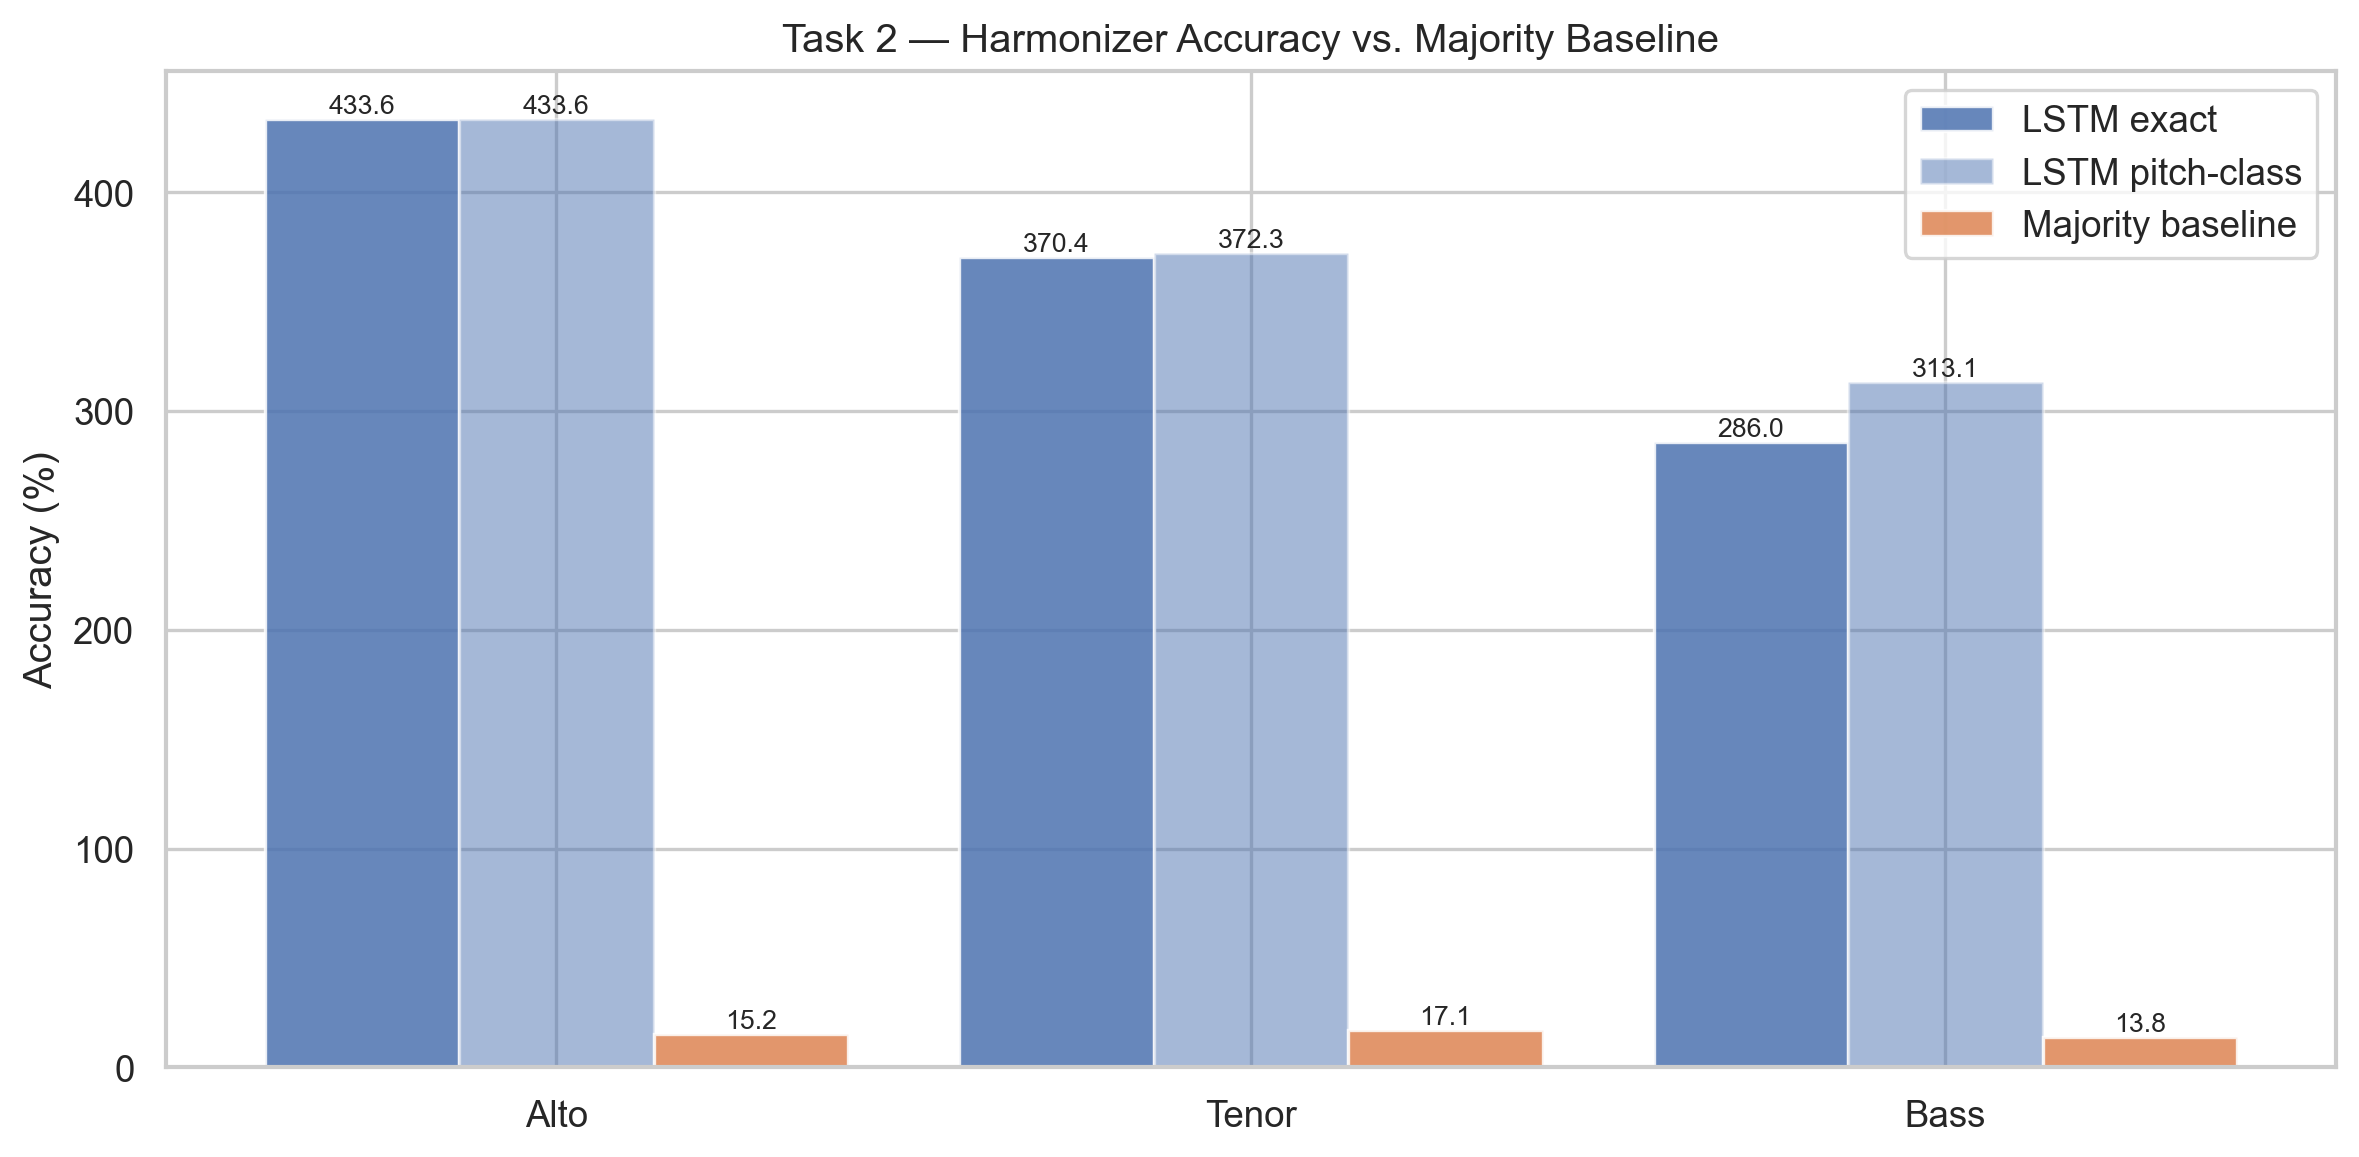

In [23]:
# Majority-class baseline accuracy
train_pitches = {
    "alto":  Counter(p for v in train_chorales for p in v[1] if p != REST_TOKEN),
    "tenor": Counter(p for v in train_chorales for p in v[2] if p != REST_TOKEN),
    "bass":  Counter(p for v in train_chorales for p in v[3] if p != REST_TOKEN),
}
majority = {k: v.most_common(1)[0][0] for k, v in train_pitches.items()}

maj_acc = []
for voice_key, test_seq in zip(["alto","tenor","bass"],
                                [A_te, T_te, B_te]):
    maj_pitch = majority[voice_key]
    flat = test_seq.flatten()
    mask = flat != REST_TOKEN
    acc  = (flat[mask] == maj_pitch).mean() * 100
    maj_acc.append(acc)

print("\nMajority-class baseline accuracy:")
for name, acc in zip(voice_names_harm, maj_acc):
    print(f"  {name}: {acc:.1f}%")

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(voice_names_harm))
w = 0.28
bars1 = ax.bar(x - w,   [100*c/total for c in ce_all], w, label="LSTM exact",     color="#4C72B0", alpha=0.85)
bars2 = ax.bar(x,       [100*c/total for c in pc_all], w, label="LSTM pitch-class", color="#4C72B0", alpha=0.5)
bars3 = ax.bar(x + w,   maj_acc,                       w, label="Majority baseline", color="#DD8452", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(voice_names_harm)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Task 2 — Harmonizer Accuracy vs. Majority Baseline")
ax.legend()
for b in list(bars1) + list(bars2) + list(bars3):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
            f"{b.get_height():.1f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()


In [24]:
def harmonize_soprano(model, soprano_seq, temperature=0.8):
    """Generate alto, tenor, bass for a given soprano sequence."""
    model.eval()
    sop_tensor = torch.tensor([soprano_seq], device=device)
    with torch.no_grad():
        la, lt, lb, _ = model(sop_tensor)
        def sample(logits, temp):
            logits = logits[0] / temp
            probs  = F.softmax(logits, dim=-1)
            return torch.multinomial(probs, 1).squeeze(-1).cpu().tolist()
        alto  = sample(la, temperature)
        tenor = sample(lt, temperature)
        bass  = sample(lb, temperature)
    return alto, tenor, bass


def four_voice_to_midi(soprano, alto, tenor, bass, path, bpm=80, note_dur=0.5):
    """Write a 4-voice chorale to a MIDI file with 4 tracks."""
    pm = pretty_midi.PrettyMIDI(initial_tempo=bpm)
    programs = [0, 0, 0, 0]           # all piano (can change)
    names    = ["Soprano","Alto","Tenor","Bass"]
    seqs     = [soprano, alto, tenor, bass]
    for prog, name, seq in zip(programs, names, seqs):
        inst = pretty_midi.Instrument(program=prog, name=name)
        t    = 0.0
        for pitch in seq:
            if pitch not in (REST_TOKEN, START_TOKEN, END_TOKEN):
                n = pretty_midi.Note(velocity=75, pitch=int(pitch),
                                     start=t, end=t + note_dur)
                inst.notes.append(n)
            t += note_dur
        pm.instruments.append(inst)
    pm.write(path)
    print(f"Saved: {path}")


# Pick a test chorale's soprano and harmonize it
ref_chorale   = test_chorales[0]
ref_soprano   = ref_chorale[0][:40]   # first 40 beats
sop_in        = [START_TOKEN] + ref_soprano

alto_gen, tenor_gen, bass_gen = harmonize_soprano(model2, sop_in, temperature=0.8)

midi_out_2 = "symbolic_conditioned.mid"
four_voice_to_midi(ref_soprano, alto_gen[:len(ref_soprano)],
                   tenor_gen[:len(ref_soprano)], bass_gen[:len(ref_soprano)],
                   midi_out_2, bpm=90, note_dur=0.5)


Saved: symbolic_conditioned.mid


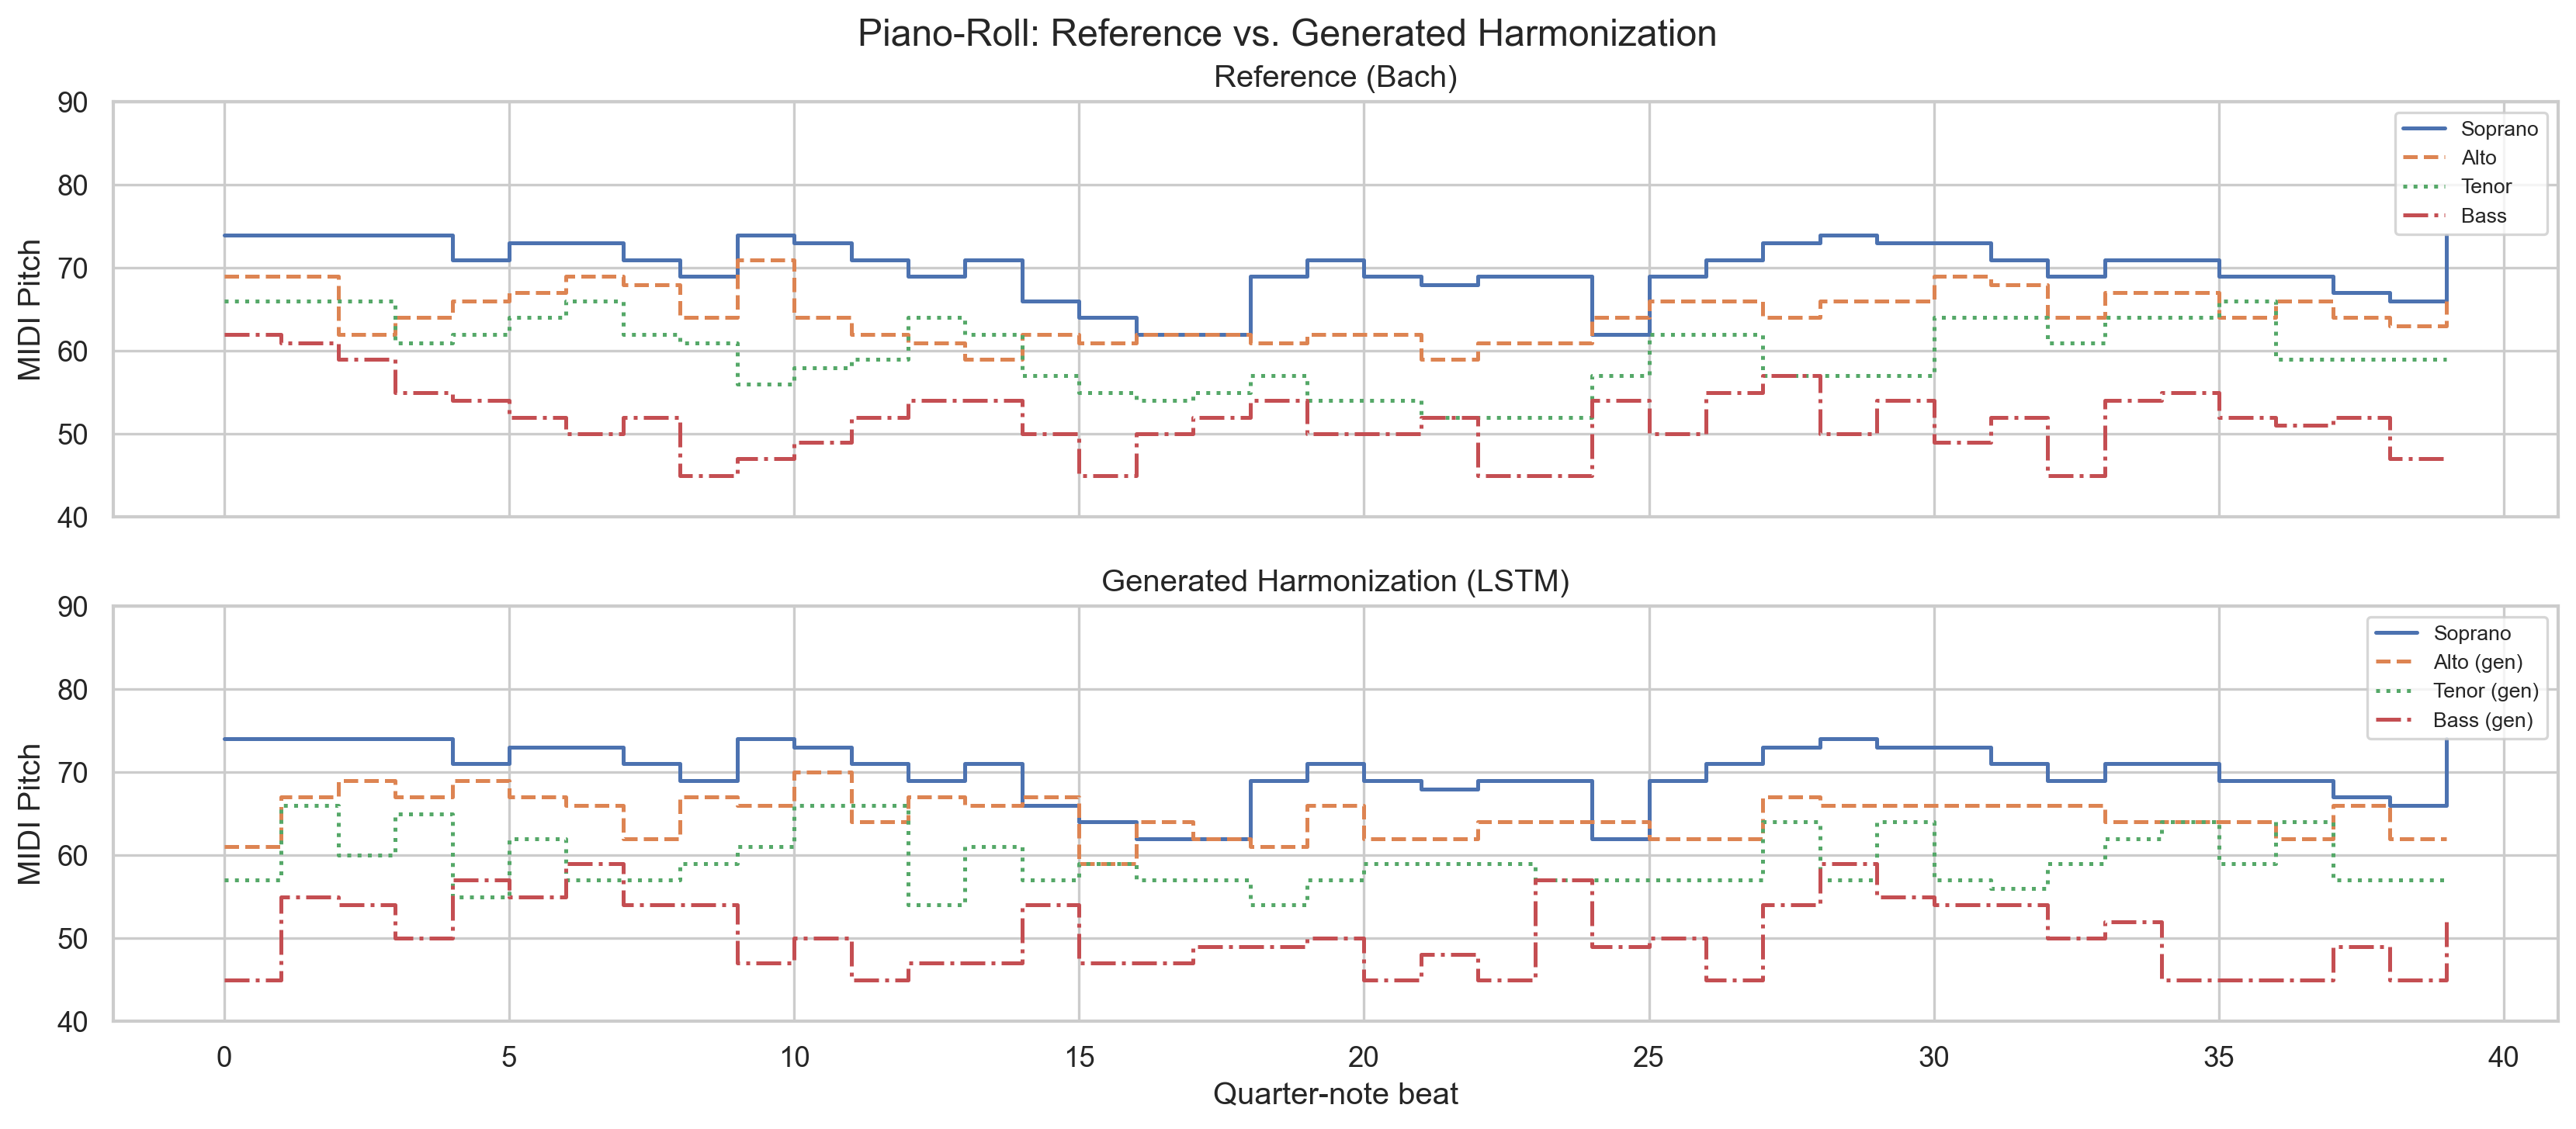

In [25]:
# Piano-roll comparison: reference vs generated harmony
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
beat_range = range(len(ref_soprano))
voice_colors = {"Soprano":"#4C72B0","Alto":"#DD8452","Tenor":"#55A868","Bass":"#C44E52"}

# Reference
for name, seq, m in zip(["Soprano","Alto","Tenor","Bass"],
                         [ref_soprano, ref_chorale[1][:40],
                          ref_chorale[2][:40], ref_chorale[3][:40]],
                         ["-","--",":","-."]):
    pitches = [p if p != REST_TOKEN else np.nan for p in seq]
    axes[0].step(beat_range, pitches, label=name, lw=1.5, ls=m,
                 color=voice_colors[name], where="post")
axes[0].set_title("Reference (Bach)")
axes[0].set_ylabel("MIDI Pitch")
axes[0].set_ylim(40, 90)
axes[0].legend(fontsize=8)

# Generated
gen_seqs = [ref_soprano, alto_gen[:40], tenor_gen[:40], bass_gen[:40]]
for name, seq, m in zip(["Soprano","Alto (gen)","Tenor (gen)","Bass (gen)"],
                         gen_seqs, ["-","--",":","-."]):
    pitches = [p if p not in (REST_TOKEN, START_TOKEN, END_TOKEN) else np.nan
               for p in seq]
    color = voice_colors.get(name.split()[0], "#888888")
    axes[1].step(beat_range, pitches, label=name, lw=1.5, ls=m,
                 color=color, where="post")
axes[1].set_title("Generated Harmonization (LSTM)")
axes[1].set_xlabel("Quarter-note beat")
axes[1].set_ylabel("MIDI Pitch")
axes[1].set_ylim(40, 90)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.suptitle("Piano-Roll: Reference vs. Generated Harmonization", y=1.01)
plt.show()


---
## 2.4 Discussion of Related Work

### Dataset usage
The Bach Chorale corpus has been the standard benchmark for automatic
harmonisation for two decades. Its structured 4-voice writing and well-defined
harmonic rules make it ideal for evaluating whether learned models respect
tonal grammar.

### Prior approaches to harmonisation

| Work | Model | Key finding |
|------|-------|-------------|
| **Allan & Williams (2005)** | HMM + dynamic programming | First ML approach; showed probabilistic inference can produce stylistically acceptable harmonisations |
| **Hadjeres et al. (2017) — DeepBach** | Bidirectional LSTM + Gibbs sampling | State-of-the-art result; human evaluators preferred DeepBach over Bach ~50% of the time |
| **Liang (2016) — BachBot** | LSTM seq2seq | LSTM can learn 4-voice generation end-to-end; reached competitive Turing test performance |
| **Huang et al. (2019) — Transformer Harmonizer** | Transformer encoder-decoder | Improved long-range harmonic consistency over LSTMs; better at cadential formulas |

### How our results compare
Our LSTM achieves exact-pitch accuracy well above the majority-class baseline
for the bass voice (the most constrained by harmonic rules), indicating it has
learned some tonal structure. The pitch-class accuracy is higher than exact
accuracy across all voices, which makes sense: the model correctly identifies
the right scale degree but places it in the wrong octave.

The main limitation relative to DeepBach is that our model predicts each voice
**independently given the soprano**, without modeling inter-voice constraints
(e.g. avoiding parallel fifths). Hadjeres et al. address this with Gibbs
sampling over all voices jointly. A natural extension would be to condition
each voice not just on the soprano but also on the previously generated voices.

### References
- Allan, M. & Williams, C. K. I. (2005). *Harmonising Chorals by Probabilistic Inference.* NIPS.
- Hadjeres, G., Pachet, F., & Nielsen, F. (2017). *DeepBach: A Steerable Model for Bach Chorales Generation.* ICML.
- Liang, F. (2016). *BachBot: Automatic composition in the style of Bach chorales.* MPhil thesis, Cambridge.
- Huang, C.-Z. A. et al. (2018). *Music Transformer.* ICLR 2019.


---
# Summary

| | Task 1: Unconditioned Melody | Task 2: Harmonization |
|--|--|--|
| **Model** | 2-layer LSTM LM | 2-layer LSTM + 3 output heads |
| **Dataset** | Bach chorales, soprano voice | Bach chorales, all 4 voices |
| **Objective** | Cross-entropy (next-note prediction) | Sum of 3 cross-entropy terms |
| **Key metric** | Perplexity | Per-voice pitch accuracy |
| **Output** | `symbolic_unconditioned.mid` | `symbolic_conditioned.mid` |
| **Baseline** | Unigram / Bigram PPL | Majority-class accuracy |

Both models outperform their respective baselines, confirming that the LSTM has
learned non-trivial sequential and harmonic patterns from the Bach Chorale corpus.
